# Data Analysis ~ 100

In [1]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## X1.0 ~ Single | Baseline

passage_time: 10; interval: 3; window: 3

In [2]:
x10_folder_path = '../infra/reports/seq-single_baseline'

### Predict

In [3]:
from pandas import json_normalize
import json

with open(f'{x10_folder_path}/metrics.json') as f:
    x10_data = json.load(f)

load_model_duration = datetime.fromisoformat(x10_data['load_model_final']) - datetime.fromisoformat(x10_data['load_model_start'])
    
rows = []
for animal, v1 in x10_data['animals'].items():
    row_base = {
        'pid': x10_data['pid'],
        'load_model_start': datetime.fromisoformat(x10_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x10_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images': v1['total_of_images'],
        'suitable_images': v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        row = row_base.copy()
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx10_metrics_v0 = pd.DataFrame.from_dict(rows)
dx10_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:01.432159,2026-04-29 17:52:02.290545
1,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:03.289182,2026-04-29 17:52:04.142837
2,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:15.145372,2026-04-29 17:52:15.999223
3,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:16.994923,2026-04-29 17:52:17.846081
4,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,3,2026-04-29 17:52:27.843096,2026-04-29 17:52:37.518255,2026-04-29 17:52:38.511188,9,2,2026-04-29 17:52:28.835319,2026-04-29 17:52:29.671525


In [4]:
dx10_metrics_v0['img_weight_prediction_dur'] = dx10_metrics_v0['weight_prediction_final'] - dx10_metrics_v0['weight_prediction_start']
dx10_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur
0,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:01.432159,2026-04-29 17:52:02.290545,0 days 00:00:00.858386
1,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:03.289182,2026-04-29 17:52:04.142837,0 days 00:00:00.853655
2,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:15.145372,2026-04-29 17:52:15.999223,0 days 00:00:00.853851
3,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:16.994923,2026-04-29 17:52:17.846081,0 days 00:00:00.851158
4,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,3,2026-04-29 17:52:27.843096,2026-04-29 17:52:37.518255,2026-04-29 17:52:38.511188,9,2,2026-04-29 17:52:28.835319,2026-04-29 17:52:29.671525,0 days 00:00:00.836206


In [5]:
by_animal_dict = []

for animal, by_animal in dx10_metrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['img_weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

dx10_metrics_v1 = dx10_metrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
dx10_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:01.432159,2026-04-29 17:52:02.290545,0 days 00:00:00.858386,0 days 00:00:10.880700,0 days 00:00:01.712041,0 days 00:00:00.993144
1,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:03.289182,2026-04-29 17:52:04.142837,0 days 00:00:00.853655,0 days 00:00:10.880700,0 days 00:00:01.712041,0 days 00:00:00.993144
2,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:15.145372,2026-04-29 17:52:15.999223,0 days 00:00:00.853851,0 days 00:00:10.708769,0 days 00:00:01.705009,0 days 00:00:01.003162
3,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:16.994923,2026-04-29 17:52:17.846081,0 days 00:00:00.851158,0 days 00:00:10.708769,0 days 00:00:01.705009,0 days 00:00:01.003162
4,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,3,2026-04-29 17:52:27.843096,2026-04-29 17:52:37.518255,2026-04-29 17:52:38.511188,9,2,2026-04-29 17:52:28.835319,2026-04-29 17:52:29.671525,0 days 00:00:00.836206,0 days 00:00:10.668092,0 days 00:00:01.692625,0 days 00:00:00.992933


In [6]:
collect_lead_time = dx10_metrics_v1['display_time'].max() - dx10_metrics_v1['first_image_capture_time'].min()
qtt = len(dx10_metrics_v1['animal'].unique())

dx10_metrics_v1['collect_lead_time'] = collect_lead_time
dx10_metrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx10_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:01.432159,2026-04-29 17:52:02.290545,0 days 00:00:00.858386,0 days 00:00:10.880700,0 days 00:00:01.712041,0 days 00:00:00.993144,0 days 00:22:43.823568,263.963762
1,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,1,2026-04-29 17:52:00.251692,2026-04-29 17:52:10.139248,2026-04-29 17:52:11.132392,9,2,2026-04-29 17:52:03.289182,2026-04-29 17:52:04.142837,0 days 00:00:00.853655,0 days 00:00:10.880700,0 days 00:00:01.712041,0 days 00:00:00.993144,0 days 00:22:43.823568,263.963762
2,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:15.145372,2026-04-29 17:52:15.999223,0 days 00:00:00.853851,0 days 00:00:10.708769,0 days 00:00:01.705009,0 days 00:00:01.003162,0 days 00:22:43.823568,263.963762
3,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,2,2026-04-29 17:52:14.132581,2026-04-29 17:52:23.838188,2026-04-29 17:52:24.841350,9,2,2026-04-29 17:52:16.994923,2026-04-29 17:52:17.846081,0 days 00:00:00.851158,0 days 00:00:10.708769,0 days 00:00:01.705009,0 days 00:00:01.003162,0 days 00:22:43.823568,263.963762
4,single_2026-04-29T17:51:53.252645,2026-04-29 17:51:53.253353,2026-04-29 17:52:00.251570,0 days 00:00:06.998217,3,2026-04-29 17:52:27.843096,2026-04-29 17:52:37.518255,2026-04-29 17:52:38.511188,9,2,2026-04-29 17:52:28.835319,2026-04-29 17:52:29.671525,0 days 00:00:00.836206,0 days 00:00:10.668092,0 days 00:00:01.692625,0 days 00:00:00.992933,0 days 00:22:43.823568,263.963762


In [7]:
dx10_metrics_v1[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,200.0,200.0,200,200,2.000000e+02
mean,9.0,2.0,0 days 00:00:01.707978,0 days 00:00:00.992577,2.639638e+02
std,0.0,0.0,0 days 00:00:00.014467,0 days 00:00:00.008684,5.698606e-14
min,9.0,2.0,0 days 00:00:01.676673,0 days 00:00:00.972976,2.639638e+02
25%,9.0,2.0,0 days 00:00:01.696501,0 days 00:00:00.987333,2.639638e+02
50%,9.0,2.0,0 days 00:00:01.708250,0 days 00:00:00.992889,2.639638e+02
75%,9.0,2.0,0 days 00:00:01.719414,0 days 00:00:00.998254,2.639638e+02
max,9.0,2.0,0 days 00:00:01.738805,0 days 00:00:01.011330,2.639638e+02


In [190]:
dx10_metrics_v1.groupby('animal')['by_animal_processing_delay'].mean().reset_index(name='time')['time'].sum()

Timedelta('0 days 00:02:50.797875')

In [9]:
total_of_imgs = dx10_metrics_v1.groupby('animal')['total_of_images'].mean().reset_index(name='qtd')['qtd'].sum()
total_time = pd.to_timedelta(dx10_metrics_v1['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 900.0 - Time: 0 days 00:22:43.823568 => FPS:0.6599094055250994


### CPU

In [10]:
dx10_cpu = pd.read_csv(f'{x10_folder_path}/cpu.csv')

dx10_cpu['timestamp'] = dx10_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx10_cpu['cpu_mean']  = dx10_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx10_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-29 17:51:54.254526,4.0,95.0,4.0,4.9,26.975
1,2026-04-29 17:51:55.259754,10.1,73.0,11.9,30.3,31.325
2,2026-04-29 17:51:56.275670,0.0,0.0,0.0,99.0,24.750
3,2026-04-29 17:51:57.276463,1.0,0.0,1.0,53.5,13.875
4,2026-04-29 17:51:58.277004,0.0,0.0,0.0,3.0,0.750


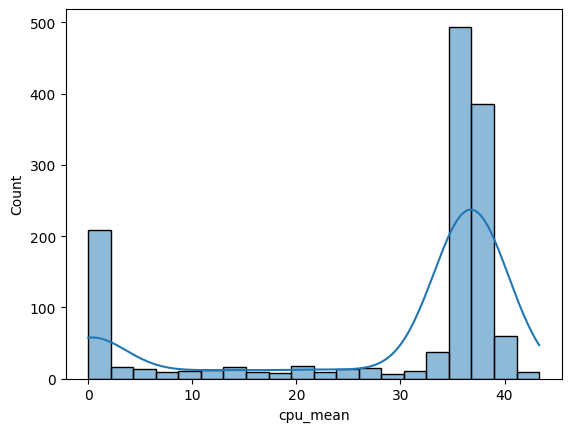

In [11]:
sns.histplot(data=dx10_cpu, x="cpu_mean", kde=True)
plt.show()

In [12]:
dx10_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1368,1368.000000,1368.000000,1368.000000,1368.000000,1368.000000
mean,2026-04-29 18:03:20.337789,27.159795,32.196784,30.646126,24.870906,28.718403
min,2026-04-29 17:51:54.254526,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-29 17:57:37.180478,15.500000,17.200000,17.200000,15.600000,24.750000
50%,2026-04-29 18:03:20.374752,22.000000,28.150000,26.950000,21.200000,36.175000
75%,2026-04-29 18:09:03.471079,39.000000,48.125000,45.500000,35.700000,37.200000
max,2026-04-29 18:14:46.454254,91.800000,95.000000,91.100000,99.000000,43.325000
std,NaN,21.378000,23.580839,22.316847,18.353497,14.203961


In [206]:
threshold = dx10_cpu['cpu_mean'].quantile(0.95)
dx10_cpu[dx10_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,69,69.000000,69.000000,69.000000,69.000000,69.000000
mean,2026-04-29 18:03:01.015760,39.555072,44.427536,42.475362,33.471014,39.982246
min,2026-04-29 17:52:15.302181,21.800000,21.200000,21.000000,21.000000,39.025000
25%,2026-04-29 17:57:31.418586,26.500000,29.600000,28.300000,24.500000,39.250000
50%,2026-04-29 18:02:57.774125,32.400000,41.200000,35.900000,28.200000,39.700000
75%,2026-04-29 18:07:59.999945,46.200000,56.600000,55.800000,39.800000,40.275000
max,2026-04-29 18:14:09.323638,83.000000,91.900000,88.900000,84.700000,43.325000
std,NaN,17.663226,16.929185,18.392161,13.268152,0.957239


### RAM

In [14]:
dx10_ram = pd.read_csv(f'{x10_folder_path}/mem.csv')
dx10_ram['timestamp'] = dx10_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx10_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-29 17:51:53.253551,17002643456,16408985600,593657856,3.5,15824912384,721207296,185958400,39976960,662011904
1,2026-04-29 17:51:54.254247,17002643456,16346529792,656113664,3.9,15759523840,756416512,187219968,39976960,664895488
2,2026-04-29 17:51:55.265042,17002643456,16293560320,709083136,4.2,15706554368,825999360,187219968,39976960,664895488
3,2026-04-29 17:51:56.275732,17002643456,16254713856,747929600,4.4,15667544064,857505792,187252736,40009728,665026560
4,2026-04-29 17:51:57.276339,17002643456,16053239808,949403648,5.6,15419080704,992968704,234225664,40009728,712507392


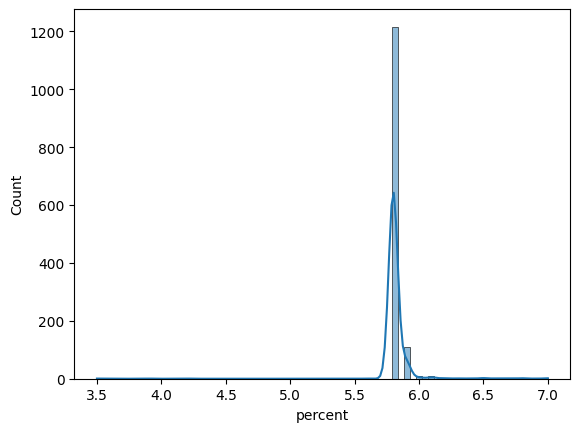

In [15]:
sns.histplot(data=dx10_ram, x="percent", kde=True)
plt.show()

In [16]:
dx10_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1371,1.371000e+03,1.371000e+03,1.371000e+03,1371.000000,1.371000e+03,1.371000e+03,1.371000e+03,1.371000e+03,1.371000e+03
mean,2026-04-29 18:03:20.266406,1.700264e+10,1.600971e+10,9.929331e+08,5.818454,1.526093e+10,1.218345e+09,3.450758e+08,4.019094e+07,8.265615e+08
min,2026-04-29 17:51:53.253551,1.700264e+10,1.581489e+10,5.936579e+08,3.500000,1.506571e+10,7.212073e+08,1.859584e+08,3.997696e+07,6.620119e+08
25%,2026-04-29 17:57:36.744493,1.700264e+10,1.601035e+10,9.894953e+08,5.800000,1.526085e+10,1.219396e+09,3.455058e+08,4.005888e+07,8.270971e+08
50%,2026-04-29 18:03:20.250223,1.700264e+10,1.601172e+10,9.909207e+08,5.800000,1.526237e+10,1.220116e+09,3.455058e+08,4.005888e+07,8.270971e+08
75%,2026-04-29 18:09:03.772024,1.700264e+10,1.601315e+10,9.922970e+08,5.800000,1.526381e+10,1.221165e+09,3.458499e+08,4.040294e+07,8.272118e+08
max,2026-04-29 18:14:47.319384,1.700264e+10,1.640899e+10,1.187758e+09,7.000000,1.582491e+10,1.222427e+09,3.458499e+08,4.041933e+07,8.273756e+08
std,NaN,0.000000e+00,2.483582e+07,2.483582e+07,0.148774,3.178367e+07,2.529368e+07,9.086875e+06,1.700960e+05,9.334713e+06


In [207]:
threshold = dx10_ram['percent'].quantile(0.95)
dx10_ram[dx10_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,39,3.900000e+01,3.900000e+01,3.900000e+01,39.000000,3.900000e+01,3.900000e+01,3.900000e+01,3.900000e+01,3.900000e+01
mean,2026-04-29 17:52:58.042979,1.700264e+10,1.592269e+10,1.079953e+09,6.353846,1.517426e+10,1.206127e+09,3.450000e+08,4.004292e+07,8.263438e+08
min,2026-04-29 17:51:58.277064,1.700264e+10,1.581489e+10,1.012580e+09,6.000000,1.506571e+10,9.980477e+08,3.275653e+08,4.000973e+07,8.056177e+08
25%,2026-04-29 17:52:07.792335,1.700264e+10,1.588251e+10,1.032675e+09,6.100000,1.513334e+10,1.218068e+09,3.454730e+08,4.002611e+07,8.270971e+08
50%,2026-04-29 17:52:17.300712,1.700264e+10,1.594119e+10,1.061454e+09,6.200000,1.519201e+10,1.218068e+09,3.454730e+08,4.002611e+07,8.270971e+08
75%,2026-04-29 17:52:26.817393,1.700264e+10,1.596997e+10,1.120133e+09,6.600000,1.522260e+10,1.218068e+09,3.454730e+08,4.002611e+07,8.270971e+08
max,2026-04-29 18:05:50.749005,1.700264e+10,1.599006e+10,1.187758e+09,7.000000,1.524046e+10,1.220329e+09,3.458335e+08,4.038656e+07,8.272118e+08
std,NaN,0.000000e+00,5.651334e+07,5.651334e+07,0.334700,5.711029e+07,4.280095e+07,2.869966e+06,8.109555e+04,3.524423e+06


### Power

In [18]:
dx10_power = pd.read_csv(f'{x10_folder_path}/power.csv')
dx10_power['timestamp'] = dx10_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx10_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-29T17:51:42.944064,0.0,5.1082,0.71110,3.6266,2026-04-29 17:51:42.944064
1,2026-04-29T17:51:43.963627,1.0,5.1033,0.80393,4.1000,2026-04-29 17:51:43.963627
2,2026-04-29T17:51:44.938959,2.0,5.1034,0.82634,4.2143,2026-04-29 17:51:44.938959
3,2026-04-29T17:51:45.960681,3.0,5.1083,0.81408,4.1518,2026-04-29 17:51:45.960681
4,2026-04-29T17:51:46.935632,4.0,5.1085,0.80002,4.0801,2026-04-29 17:51:46.935632


In [19]:
dx10_power = dx10_power.sort_values('timestamp')

# Time difference in hours
dx10_power['dt_hours'] = dx10_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx10_power['energy_Wh'] = dx10_power['Power[W]'] * dx10_power['dt_hours']

# Total energy
total_energy_Wh = dx10_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.991429368945083
Total energy (kWh): 0.001991429368945083


In [20]:
dx10_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1387.000000,1387.000000,1387.000000,1387.000000,1387,1386.000000,1386.000000
mean,693.127469,5.107646,1.013438,5.170504,2026-04-29 18:03:16.080616,0.000278,0.001437
min,0.000000,5.085800,0.591970,3.019000,2026-04-29 17:51:42.944064,0.000269,0.000816
25%,346.600000,5.105800,0.965760,4.925550,2026-04-29 17:57:29.516888,0.000271,0.001348
50%,693.100000,5.108300,1.051310,5.363800,2026-04-29 18:03:16.098159,0.000283,0.001491
75%,1039.700000,5.110000,1.126700,5.746150,2026-04-29 18:09:02.644476,0.000284,0.001599
max,1386.300000,5.121200,1.491620,7.607200,2026-04-29 18:14:49.218061,0.000285,0.002094
std,400.612568,0.004556,0.181917,0.928588,NaN,0.000006,0.000260


## X2.0 ~ Baseline

passage_time: 10; interval: 3; window: 3

In [21]:
x20_folder_path = '../infra/reports/seq-batch_baseline'

### Predict

In [22]:
from pandas import json_normalize
import json

with open(f'{x20_folder_path}/metrics.json') as f:
    x20_data = json.load(f)

load_model_duration = datetime.fromisoformat(x20_data['load_model_final']) - datetime.fromisoformat(x20_data['load_model_start'])
    
rows = []
for animal, v1 in x20_data['animals'].items():
    row = {
        'pid': x20_data['pid'],
        'load_model_start': datetime.fromisoformat(x20_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x20_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx20_metrics_v0 = pd.DataFrame.from_dict(rows)
dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,1,2026-04-29 18:16:17.267181,2026-04-29 18:16:26.313561,2026-04-29 18:16:28.604510,10,3,2026-04-29 18:16:27.307233,2026-04-29 18:16:28.604426
1,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,2,2026-04-29 18:16:31.604624,2026-04-29 18:16:41.486816,2026-04-29 18:16:44.006924,11,4,2026-04-29 18:16:42.483703,2026-04-29 18:16:44.006849
2,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,3,2026-04-29 18:16:47.008660,2026-04-29 18:16:56.923290,2026-04-29 18:16:59.199797,11,3,2026-04-29 18:16:57.904857,2026-04-29 18:16:59.199732
3,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,4,2026-04-29 18:17:02.201447,2026-04-29 18:17:12.086443,2026-04-29 18:17:14.598742,11,4,2026-04-29 18:17:13.075972,2026-04-29 18:17:14.598679
4,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,5,2026-04-29 18:17:17.600673,2026-04-29 18:17:27.480475,2026-04-29 18:17:29.766382,11,3,2026-04-29 18:17:28.465407,2026-04-29 18:17:29.766318


In [23]:
dx20_metrics_v0['by_animal_lead_time'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['first_image_capture_time']
dx20_metrics_v0['by_animal_processing_delay'] = dx20_metrics_v0['weight_prediction_final'] - dx20_metrics_v0['weight_prediction_start']
dx20_metrics_v0['by_animal_latency'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['last_image_capture_time']

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,1,2026-04-29 18:16:17.267181,2026-04-29 18:16:26.313561,2026-04-29 18:16:28.604510,10,3,2026-04-29 18:16:27.307233,2026-04-29 18:16:28.604426,0 days 00:00:11.337329,0 days 00:00:01.297193,0 days 00:00:02.290949
1,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,2,2026-04-29 18:16:31.604624,2026-04-29 18:16:41.486816,2026-04-29 18:16:44.006924,11,4,2026-04-29 18:16:42.483703,2026-04-29 18:16:44.006849,0 days 00:00:12.402300,0 days 00:00:01.523146,0 days 00:00:02.520108
2,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,3,2026-04-29 18:16:47.008660,2026-04-29 18:16:56.923290,2026-04-29 18:16:59.199797,11,3,2026-04-29 18:16:57.904857,2026-04-29 18:16:59.199732,0 days 00:00:12.191137,0 days 00:00:01.294875,0 days 00:00:02.276507
3,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,4,2026-04-29 18:17:02.201447,2026-04-29 18:17:12.086443,2026-04-29 18:17:14.598742,11,4,2026-04-29 18:17:13.075972,2026-04-29 18:17:14.598679,0 days 00:00:12.397295,0 days 00:00:01.522707,0 days 00:00:02.512299
4,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,5,2026-04-29 18:17:17.600673,2026-04-29 18:17:27.480475,2026-04-29 18:17:29.766382,11,3,2026-04-29 18:17:28.465407,2026-04-29 18:17:29.766318,0 days 00:00:12.165709,0 days 00:00:01.300911,0 days 00:00:02.285907


In [24]:
collect_lead_time = dx20_metrics_v0['display_time'].max() - dx20_metrics_v0['first_image_capture_time'].min()
qtt = len(dx20_metrics_v0['animal'].unique())

dx20_metrics_v0['collect_lead_time'] = collect_lead_time
dx20_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,1,2026-04-29 18:16:17.267181,2026-04-29 18:16:26.313561,2026-04-29 18:16:28.604510,10,3,2026-04-29 18:16:27.307233,2026-04-29 18:16:28.604426,0 days 00:00:11.337329,0 days 00:00:01.297193,0 days 00:00:02.290949,0 days 00:25:30.020874,235.290908
1,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,2,2026-04-29 18:16:31.604624,2026-04-29 18:16:41.486816,2026-04-29 18:16:44.006924,11,4,2026-04-29 18:16:42.483703,2026-04-29 18:16:44.006849,0 days 00:00:12.402300,0 days 00:00:01.523146,0 days 00:00:02.520108,0 days 00:25:30.020874,235.290908
2,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,3,2026-04-29 18:16:47.008660,2026-04-29 18:16:56.923290,2026-04-29 18:16:59.199797,11,3,2026-04-29 18:16:57.904857,2026-04-29 18:16:59.199732,0 days 00:00:12.191137,0 days 00:00:01.294875,0 days 00:00:02.276507,0 days 00:25:30.020874,235.290908
3,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,4,2026-04-29 18:17:02.201447,2026-04-29 18:17:12.086443,2026-04-29 18:17:14.598742,11,4,2026-04-29 18:17:13.075972,2026-04-29 18:17:14.598679,0 days 00:00:12.397295,0 days 00:00:01.522707,0 days 00:00:02.512299,0 days 00:25:30.020874,235.290908
4,batch_2026-04-29T18:16:10.163515,2026-04-29 18:16:10.164208,2026-04-29 18:16:17.267060,0 days 00:00:07.102852,5,2026-04-29 18:17:17.600673,2026-04-29 18:17:27.480475,2026-04-29 18:17:29.766382,11,3,2026-04-29 18:17:28.465407,2026-04-29 18:17:29.766318,0 days 00:00:12.165709,0 days 00:00:01.300911,0 days 00:00:02.285907,0 days 00:25:30.020874,235.290908


In [25]:
dx20_metrics_v0[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,100.00,100.000000,100,100,100.000000
mean,10.99,3.740000,0 days 00:00:01.462156,0 days 00:00:02.451466,235.290908
std,0.10,0.440844,0 days 00:00:00.098455,0 days 00:00:00.099355,0.000000
min,10.00,3.000000,0 days 00:00:01.292124,0 days 00:00:02.272176,235.290908
25%,11.00,3.000000,0 days 00:00:01.310146,0 days 00:00:02.299141,235.290908
50%,11.00,4.000000,0 days 00:00:01.518831,0 days 00:00:02.507433,235.290908
75%,11.00,4.000000,0 days 00:00:01.521435,0 days 00:00:02.513472,235.290908
max,11.00,4.000000,0 days 00:00:01.525536,0 days 00:00:02.524290,235.290908


In [26]:
dx20_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:26.215649')

In [27]:
total_of_imgs = dx20_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx20_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 1099 - Time: 0 days 00:25:30.020874 => FPS:0.7182908538540631


### CPU

In [28]:
dx20_cpu = pd.read_csv(f'{x20_folder_path}/cpu.csv')

dx20_cpu['timestamp'] = dx20_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_cpu['cpu_mean']  = dx20_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx20_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-29 18:16:11.164968,4.0,26.3,4.0,70.0,26.075
1,2026-04-29 18:16:12.342328,17.3,30.0,24.2,51.5,30.750
2,2026-04-29 18:16:13.378849,1.0,0.0,1.0,100.0,25.500
3,2026-04-29 18:16:14.379437,0.0,1.0,1.0,36.0,9.500
4,2026-04-29 18:16:15.379859,0.0,0.0,0.0,4.0,1.000


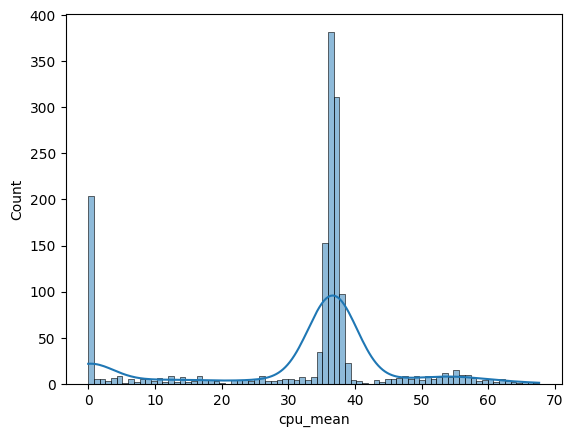

In [29]:
sns.histplot(data=dx20_cpu, x="cpu_mean", kde=True)
plt.show()

In [30]:
dx20_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1534,1534.000000,1534.000000,1534.000000,1534.000000,1534.000000
mean,2026-04-29 18:29:00.667315,28.970860,34.526206,33.279465,29.141591,31.479531
min,2026-04-29 18:16:11.164968,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-29 18:22:36.058502,17.500000,18.800000,18.400000,18.000000,34.700000
50%,2026-04-29 18:29:00.646431,25.500000,33.700000,31.200000,25.000000,36.462500
75%,2026-04-29 18:35:25.175071,42.000000,51.000000,50.000000,41.800000,37.343750
max,2026-04-29 18:41:49.948021,91.800000,91.900000,91.800000,100.000000,67.625000
std,NaN,19.830943,23.117316,22.385118,19.865235,15.340720


In [208]:
threshold = dx20_cpu['cpu_mean'].quantile(0.95)
dx20_cpu[dx20_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,77,77.000000,77.000000,77.000000,77.000000,77.000000
mean,2026-04-29 18:29:54.334751,58.740260,57.637662,59.185714,57.532468,58.274026
min,2026-04-29 18:16:43.646420,44.100000,41.700000,43.100000,41.200000,53.850000
25%,2026-04-29 18:23:37.139818,52.500000,51.500000,53.100000,51.500000,55.450000
50%,2026-04-29 18:30:16.326619,57.400000,56.400000,57.600000,56.600000,57.300000
75%,2026-04-29 18:36:39.837631,63.300000,64.400000,64.300000,64.000000,60.700000
max,2026-04-29 18:41:46.944058,86.100000,80.800000,78.200000,84.300000,67.625000
std,NaN,8.446539,8.689074,8.195373,8.450637,3.502526


### RAM

In [32]:
dx20_ram = pd.read_csv(f'{x20_folder_path}/mem.csv')
dx20_ram['timestamp'] = dx20_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-29 18:16:10.164540,17002643456,16430923776,571719680,3.4,15846965248,721321984,185827328,39960576,662093824
1,2026-04-29 18:16:11.170970,17002643456,16396713984,605929472,3.6,15809724416,757579776,187203584,39960576,664961024
2,2026-04-29 18:16:12.342211,17002643456,16311812096,690831360,4.1,15724822528,826146816,187203584,39960576,664961024
3,2026-04-29 18:16:13.353466,17002643456,16229122048,773521408,4.5,15642001408,883884032,187203584,39960576,665092096
4,2026-04-29 18:16:14.353832,17002643456,16105930752,896712704,5.3,15463579648,1000931328,242417664,39960576,720437248


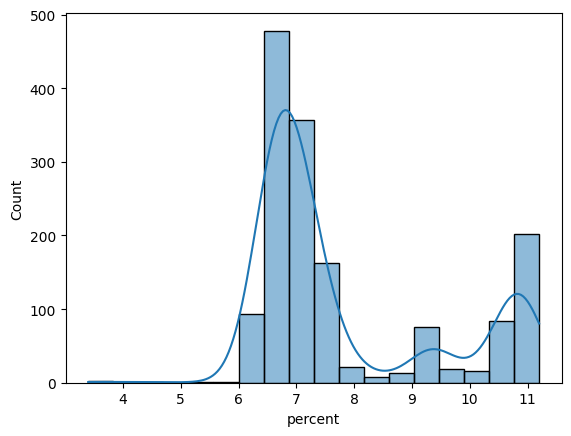

In [33]:
sns.histplot(data=dx20_ram, x="percent", kde=True)
plt.show()

In [34]:
dx20_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1536,1.536000e+03,1.536000e+03,1.536000e+03,1536.000000,1.536000e+03,1.536000e+03,1.536000e+03,1.536000e+03,1.536000e+03
mean,2026-04-29 18:29:00.373240,1.700264e+10,1.567240e+10,1.330239e+09,7.824740,1.492336e+10,1.372940e+09,3.451586e+08,4.018372e+07,8.269281e+08
min,2026-04-29 18:16:10.164540,1.700264e+10,1.510035e+10,5.717197e+08,3.400000,1.435057e+10,7.213220e+08,1.858273e+08,3.996058e+07,6.620938e+08
25%,2026-04-29 18:22:35.412727,1.700264e+10,1.542955e+10,1.138184e+09,6.700000,1.467975e+10,1.202045e+09,3.454894e+08,4.002611e+07,8.273756e+08
50%,2026-04-29 18:29:00.350615,1.700264e+10,1.580851e+10,1.194131e+09,7.000000,1.505882e+10,1.204601e+09,3.455058e+08,4.004250e+07,8.273756e+08
75%,2026-04-29 18:35:25.359387,1.700264e+10,1.586446e+10,1.573097e+09,9.225000,1.511503e+10,1.652638e+09,3.458499e+08,4.038656e+07,8.275231e+08
max,2026-04-29 18:41:50.322568,1.700264e+10,1.643092e+10,1.902297e+09,11.200000,1.584697e+10,1.902854e+09,3.458499e+08,4.038656e+07,8.276705e+08
std,NaN,0.000000e+00,2.781007e+08,2.781007e+08,1.636541,2.793946e+08,2.785947e+08,8.516239e+06,1.746080e+05,8.760758e+06


In [209]:
threshold = dx20_ram['percent'].quantile(0.95)
dx20_ram[dx20_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,67,6.700000e+01,6.700000e+01,6.700000e+01,67.000000,6.700000e+01,6.700000e+01,6.700000e+01,6.700000e+01,6.700000e+01
mean,2026-04-29 18:29:58.686219,1.700264e+10,1.512721e+10,1.875438e+09,11.040299,1.437760e+10,1.892835e+09,3.456885e+08,4.022517e+07,8.274592e+08
min,2026-04-29 18:18:31.928609,1.700264e+10,1.510035e+10,1.862058e+09,11.000000,1.435057e+10,1.828684e+09,3.454894e+08,4.002611e+07,8.273756e+08
25%,2026-04-29 18:23:09.272927,1.700264e+10,1.512022e+10,1.866711e+09,11.000000,1.437064e+10,1.892876e+09,3.454894e+08,4.002611e+07,8.273756e+08
50%,2026-04-29 18:31:49.448774,1.700264e+10,1.513349e+10,1.869152e+09,11.000000,1.438412e+10,1.893876e+09,3.458335e+08,4.037018e+07,8.275231e+08
75%,2026-04-29 18:35:54.664244,1.700264e+10,1.513593e+10,1.882423e+09,11.100000,1.438614e+10,1.896612e+09,3.458499e+08,4.038656e+07,8.275231e+08
max,2026-04-29 18:41:50.322568,1.700264e+10,1.514059e+10,1.902297e+09,11.200000,1.439121e+10,1.899577e+09,3.458499e+08,4.038656e+07,8.276705e+08
std,NaN,0.000000e+00,1.208573e+07,1.208573e+07,0.067554,1.208808e+07,1.096327e+07,1.757973e+05,1.757973e+05,7.795829e+04


### Power

In [36]:
dx20_power = pd.read_csv(f'{x20_folder_path}/power.csv')
dx20_power['timestamp'] = dx20_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx20_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-29T18:15:59.860960,0.0,5.1091,0.72612,3.7032,2026-04-29 18:15:59.860960
1,2026-04-29T18:16:00.879912,1.0,5.1064,0.86606,4.4169,2026-04-29 18:16:00.879912
2,2026-04-29T18:16:01.856555,2.0,5.1089,0.80268,4.0936,2026-04-29 18:16:01.856555
3,2026-04-29T18:16:02.875425,3.0,5.1084,0.84516,4.3103,2026-04-29 18:16:02.875425
4,2026-04-29T18:16:03.852600,4.0,5.1083,0.80600,4.1106,2026-04-29 18:16:03.852600


In [37]:
dx20_power = dx20_power.sort_values('timestamp')

# Time difference in hours
dx20_power['dt_hours'] = dx20_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx20_power['energy_Wh'] = dx20_power['Power[W]'] * dx20_power['dt_hours']

# Total energy
total_energy_Wh = dx20_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 2.3268759385031945
Total energy (kWh): 0.0023268759385031944


In [38]:
dx20_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1554.000000,1554.000000,1554.000000,1554.000000,1554,1553.000000,1553.000000
mean,776.645045,5.107673,1.056812,5.391599,2026-04-29 18:28:56.506854,0.000278,0.001498
min,0.000000,5.080800,0.592880,3.023600,2026-04-29 18:15:59.860960,0.000269,0.000852
25%,388.350000,5.105900,0.992908,5.063750,2026-04-29 18:22:28.191953,0.000271,0.001395
50%,776.600000,5.108400,1.072905,5.474000,2026-04-29 18:28:56.516950,0.000283,0.001520
75%,1164.950000,5.110000,1.157372,5.906500,2026-04-29 18:35:24.829836,0.000284,0.001643
max,1553.300000,5.128400,1.836300,9.346700,2026-04-29 18:41:53.161246,0.000285,0.002655
std,448.833125,0.005022,0.184306,0.940009,NaN,0.000006,0.000264


## X2.1

passage_time: 5; interval: 3; window: 3

In [39]:
x21_folder_path = '../infra/reports/batch_x21'

### Predict

In [40]:
from pandas import json_normalize
import json

with open(f'{x21_folder_path}/metrics.json') as f:
    x21_data = json.load(f)

load_model_duration = datetime.fromisoformat(x21_data['load_model_final']) - datetime.fromisoformat(x21_data['load_model_start'])
    
rows = []
for animal, v1 in x21_data['animals'].items():
    row = {
        'pid': x21_data['pid'],
        'load_model_start': datetime.fromisoformat(x21_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x21_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],    
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx21_metrics_v0 = pd.DataFrame.from_dict(rows)
dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814


In [41]:
dx21_metrics_v0['by_animal_lead_time'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['first_image_capture_time']
dx21_metrics_v0['by_animal_processing_delay'] = dx21_metrics_v0['weight_prediction_final'] - dx21_metrics_v0['weight_prediction_start']
dx21_metrics_v0['by_animal_latency'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['last_image_capture_time']

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367


In [42]:
collect_lead_time = dx21_metrics_v0['display_time'].max() - dx21_metrics_v0['first_image_capture_time'].min()
qtt = len(dx21_metrics_v0['animal'].unique())

dx21_metrics_v0['collect_lead_time'] = collect_lead_time
dx21_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023,0 days 00:15:39.570844,383.153652
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880,0 days 00:15:39.570844,383.153652
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612,0 days 00:15:39.570844,383.153652
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125,0 days 00:15:39.570844,383.153652
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367,0 days 00:15:39.570844,383.153652


In [43]:
dx21_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.000000,100.000000,100,100,100,100,100,100,1.000000e+02
mean,2026-04-17 17:05:50.204716,2026-04-17 17:05:57.231725,0 days 00:00:07.027009,2026-04-17 17:13:43.209451,2026-04-17 17:13:47.307275,2026-04-17 17:13:49.633486,5.050000,3.030000,2026-04-17 17:13:48.307731,2026-04-17 17:13:49.633414,0 days 00:00:06.424034,0 days 00:00:01.325684,0 days 00:00:02.326210,0 days 00:15:39.570844,3.831537e+02
min,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5.000000,3.000000,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.308333,0 days 00:00:01.295961,0 days 00:00:02.274947,0 days 00:15:39.570844,3.831537e+02
25%,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:09:49.113864,2026-04-17 17:09:53.165715,2026-04-17 17:09:55.488441,5.000000,3.000000,2026-04-17 17:09:54.164659,2026-04-17 17:09:55.488374,0 days 00:00:06.352670,0 days 00:00:01.312570,0 days 00:00:02.311899,0 days 00:15:39.570844,3.831537e+02
50%,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:13:42.918230,2026-04-17 17:13:46.955722,2026-04-17 17:13:49.276482,5.000000,3.000000,2026-04-17 17:13:47.952066,2026-04-17 17:13:49.276416,0 days 00:00:06.375167,0 days 00:00:01.319465,0 days 00:00:02.320001,0 days 00:15:39.570844,3.831537e+02
75%,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:17:37.258679,2026-04-17 17:17:41.305273,2026-04-17 17:17:43.624967,5.000000,3.000000,2026-04-17 17:17:42.308529,2026-04-17 17:17:43.624888,0 days 00:00:06.388513,0 days 00:00:01.328601,0 days 00:00:02.332950,0 days 00:15:39.570844,3.831537e+02
max,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2026-04-17 17:21:30.453131,2026-04-17 17:21:34.483733,2026-04-17 17:21:36.802665,6.000000,4.000000,2026-04-17 17:21:35.484898,2026-04-17 17:21:36.802589,0 days 00:00:07.541387,0 days 00:00:01.540708,0 days 00:00:02.542671,0 days 00:15:39.570844,3.831537e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.219043,0.171447,NaN,NaN,0 days 00:00:00.237602,0 days 00:00:00.037659,0 days 00:00:00.040480,0 days 00:00:00,1.142596e-13


In [44]:
dx21_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:12.568420')

In [45]:
total_of_imgs = dx21_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx21_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 505 - Time: 0 days 00:15:39.570844 => FPS:0.5374794282143561


### CPU

In [46]:
dx21_cpu = pd.read_csv(f'{x21_folder_path}/cpu.csv')

dx21_cpu['timestamp'] = dx21_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_cpu['cpu_mean']  = dx21_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx21_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:05:51.205827,2.0,2.0,95.0,2.0,25.250
1,2026-04-17 17:05:52.236993,34.7,15.8,28.4,46.6,31.375
2,2026-04-17 17:05:53.403491,100.0,0.9,0.9,1.7,25.875
3,2026-04-17 17:05:54.404129,35.0,1.0,1.0,0.0,9.250
4,2026-04-17 17:05:55.404549,4.0,0.0,0.0,1.0,1.250


In [47]:
dx21_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,946,946.000000,946.000000,946.000000,946.000000,946.000000
mean,2026-04-17 17:13:45.561720,27.042178,28.093129,28.242495,24.538161,26.978990
min,2026-04-17 17:05:51.205827,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-17 17:09:48.527147,5.000000,3.000000,4.000000,5.000000,5.868750
50%,2026-04-17 17:13:45.584545,21.200000,23.800000,23.600000,20.000000,35.400000
75%,2026-04-17 17:17:42.538971,43.900000,45.750000,45.400000,39.200000,37.075000
max,2026-04-17 17:21:39.720399,100.000000,93.800000,95.000000,92.900000,61.275000
std,NaN,23.262456,23.723330,23.637107,20.649589,17.629036


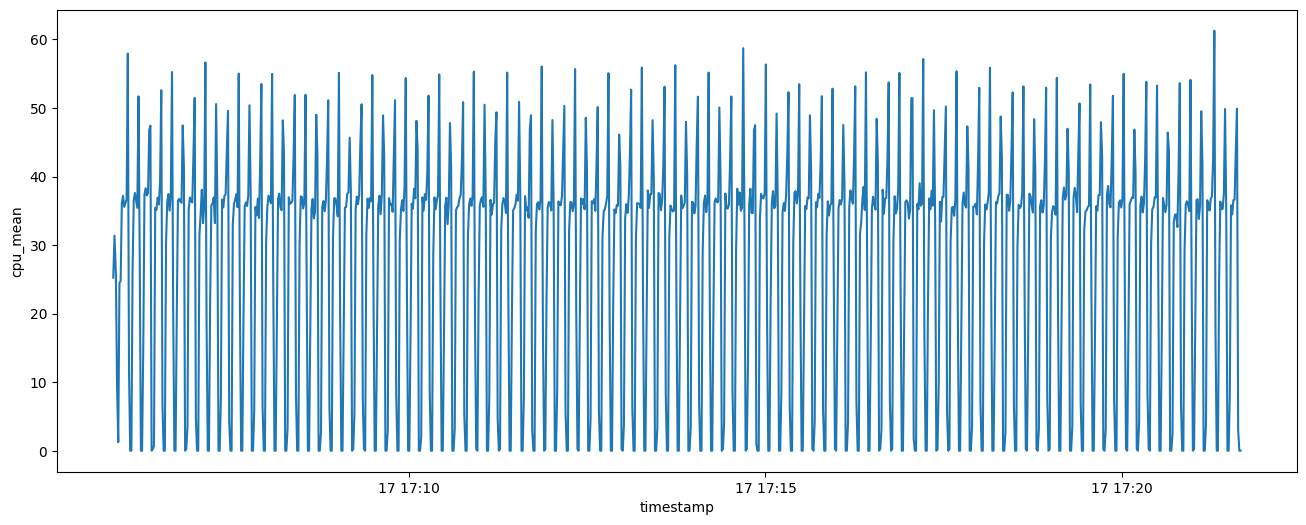

In [48]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

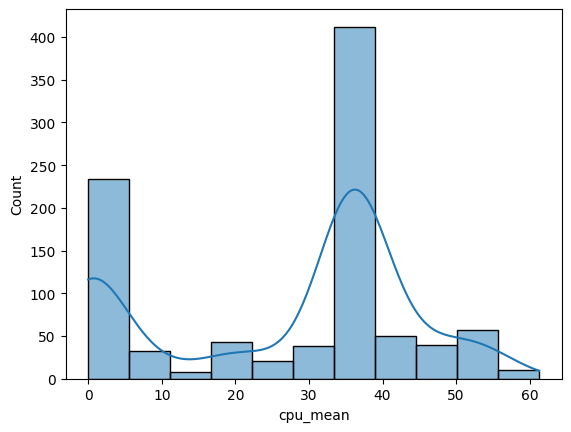

In [49]:
sns.histplot(data=dx21_cpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [50]:
dx21_ram = pd.read_csv(f'{x21_folder_path}/mem.csv')
dx21_ram['timestamp'] = dx21_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:05:50.205030,17002643456,16456679424,545964032,3.2,15874048000,720666624,184582144,38502400,661913600
1,2026-04-17 17:05:51.205898,17002643456,16418570240,584073216,3.4,15833497600,756088832,185384960,38502400,664436736
2,2026-04-17 17:05:52.221525,17002643456,16327884800,674758656,4.0,15742812160,825163776,185384960,38502400,664436736
3,2026-04-17 17:05:53.221838,17002643456,16275423232,727220224,4.3,15690219520,859160576,185384960,38502400,664567808
4,2026-04-17 17:05:54.222319,17002643456,16103407616,899235840,5.3,15471001600,991674368,232570880,38502400,712048640


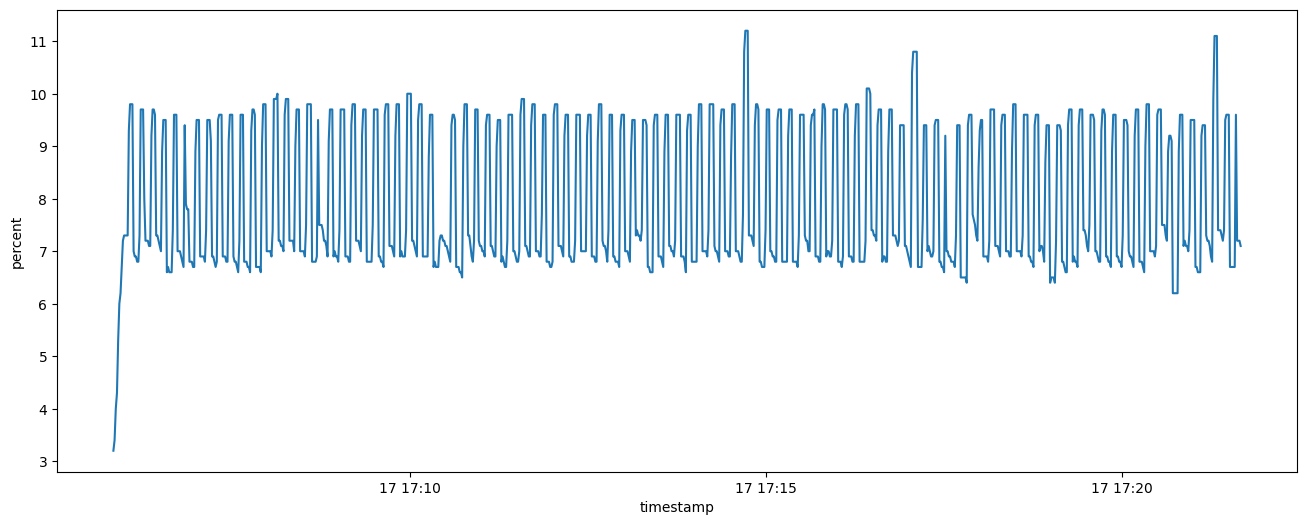

In [51]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

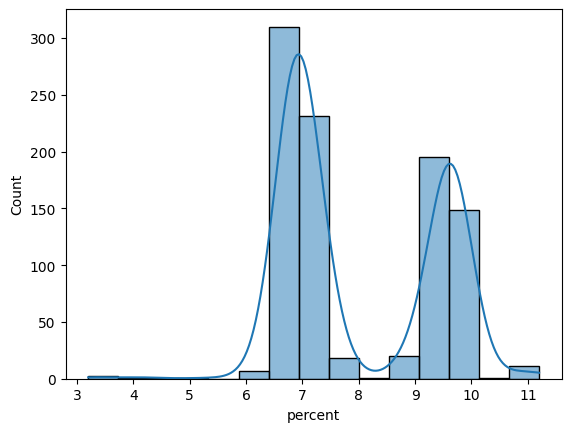

In [52]:
sns.histplot(data=dx21_ram, x="percent", kde=True)
plt.show()

In [53]:
dx21_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,948,9.480000e+02,9.480000e+02,9.480000e+02,948.000000,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02
mean,2026-04-17 17:13:45.216960,1.700264e+10,1.564315e+10,1.359498e+09,7.994831,1.489641e+10,1.401040e+09,3.429885e+08,3.870051e+07,8.260049e+08
min,2026-04-17 17:05:50.205030,1.700264e+10,1.509900e+10,5.459640e+08,3.200000,1.435163e+10,7.206666e+08,1.845821e+08,3.850240e+07,6.619136e+08
25%,2026-04-17 17:09:47.659589,1.700264e+10,1.537224e+10,1.167315e+09,6.900000,1.462482e+10,1.201111e+09,3.436216e+08,3.853517e+07,8.267694e+08
50%,2026-04-17 17:13:45.209436,1.700264e+10,1.578042e+10,1.222222e+09,7.200000,1.503272e+10,1.202946e+09,3.436216e+08,3.853517e+07,8.267694e+08
75%,2026-04-17 17:17:42.702847,1.700264e+10,1.583533e+10,1.630401e+09,9.600000,1.508764e+10,1.700053e+09,3.440968e+08,3.899392e+07,8.269824e+08
max,2026-04-17 17:21:40.399020,1.700264e+10,1.645668e+10,1.903641e+09,11.200000,1.587405e+10,1.932345e+09,3.441132e+08,3.901030e+07,8.270971e+08
std,NaN,0.000000e+00,2.330065e+08,2.330065e+08,1.367338,2.356923e+08,2.462381e+08,1.090829e+07,2.261721e+05,1.121959e+07


### Power

In [54]:
dx21_power = pd.read_csv(f'{x21_folder_path}/power.csv')
dx21_power['timestamp'] = dx21_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx21_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:05:39.967578,0.0,5.1089,0.55677,2.8395,2026-04-17 17:05:39.967578
1,2026-04-17T17:05:40.936425,1.0,5.1059,0.74729,3.8111,2026-04-17 17:05:40.936425
2,2026-04-17T17:05:41.953576,2.0,5.1088,0.77907,3.9732,2026-04-17 17:05:41.953576
3,2026-04-17T17:05:42.967824,3.0,5.1089,0.81200,4.1412,2026-04-17 17:05:42.967824
4,2026-04-17T17:05:43.939891,4.0,5.1089,0.79770,4.0682,2026-04-17 17:05:43.939891


In [55]:
dx21_power = dx21_power.sort_values('timestamp')

# Time difference in hours
dx21_power['dt_hours'] = dx21_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx21_power['energy_Wh'] = dx21_power['Power[W]'] * dx21_power['dt_hours']

# Total energy
total_energy_Wh = dx21_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.3589765710449444
Total energy (kWh): 0.0013589765710449444


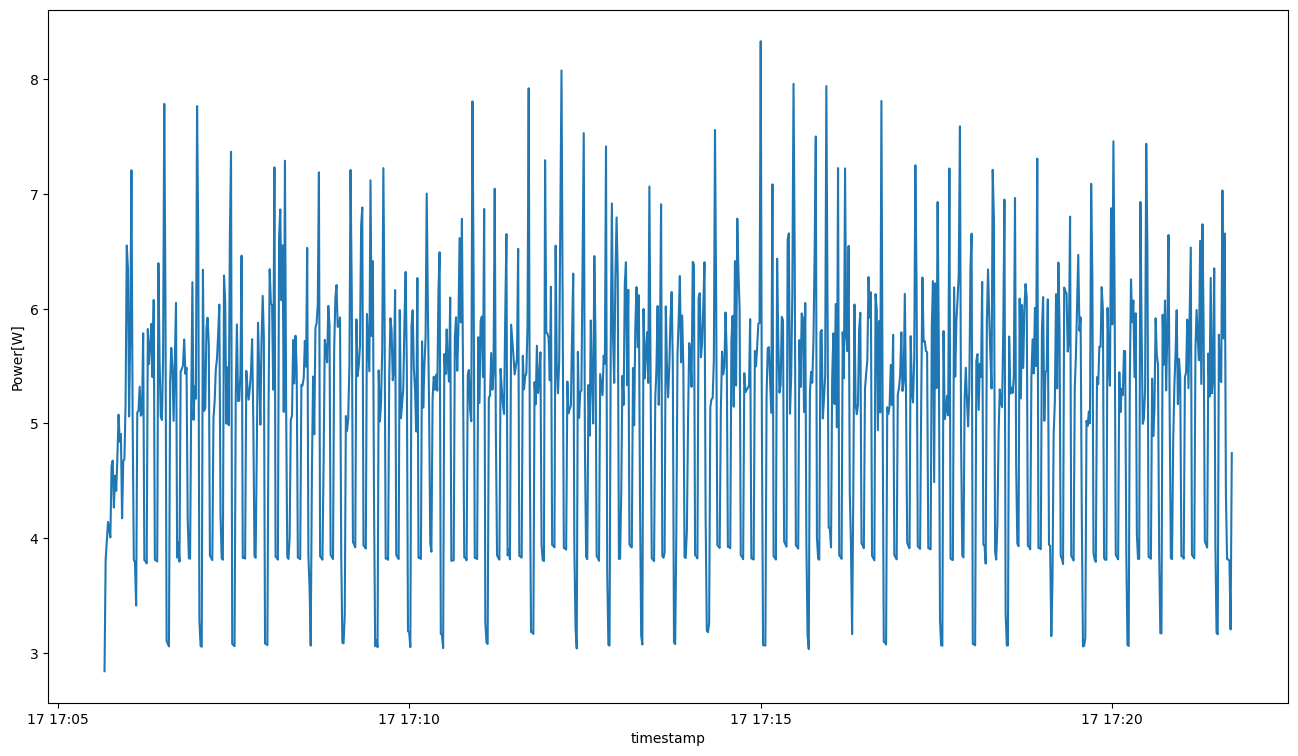

In [56]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=dx21_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

In [57]:
dx21_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,963.000000,963.000000,963.000000,963.000000,963,962.000000,962.000000
mean,481.051506,5.108512,0.996084,5.082774,2026-04-17 17:13:41.006216,0.000278,0.001413
min,0.000000,5.081600,0.556770,2.839500,2026-04-17 17:05:39.967578,0.000269,0.000823
25%,240.500000,5.106800,0.767330,3.914350,2026-04-17 17:09:40.466345,0.000271,0.001090
50%,481.100000,5.108900,1.039610,5.308100,2026-04-17 17:13:41.006946,0.000283,0.001471
75%,721.600000,5.110500,1.139720,5.822300,2026-04-17 17:17:41.542701,0.000283,0.001619
max,962.100000,5.126600,1.633880,8.332700,2026-04-17 17:21:42.073095,0.000285,0.002357
std,278.181740,0.004876,0.215800,1.101655,NaN,0.000006,0.000307


## X2.2

passage_time: 05; interval: 3; window: 2

In [58]:
x22_folder_path = '../infra/reports/batch_x22'

### Predict

In [59]:
from pandas import json_normalize
import json

with open(f'{x22_folder_path}/metrics.json') as f:
    x22_data = json.load(f)

load_model_duration = datetime.fromisoformat(x22_data['load_model_final']) - datetime.fromisoformat(x22_data['load_model_start'])
    
rows = []
for animal, v1 in x22_data['animals'].items():
    row = {
        'pid': x22_data['pid'],
        'load_model_start': datetime.fromisoformat(x22_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x22_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx22_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799


In [60]:
dx22_metrics_v0['by_animal_lead_time'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['first_image_capture_time']
dx22_metrics_v0['by_animal_processing_delay'] = dx22_metrics_v0['weight_prediction_final'] - dx22_metrics_v0['weight_prediction_start']
dx22_metrics_v0['by_animal_latency'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['last_image_capture_time']

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143


In [61]:
collect_lead_time = dx22_metrics_v0['display_time'].max() - dx22_metrics_v0['first_image_capture_time'].min()
qtt = len(dx22_metrics_v0['animal'].unique())

dx22_metrics_v0['collect_lead_time'] = collect_lead_time
dx22_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870,0 days 00:15:12.280985,394.615262
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252,0 days 00:15:12.280985,394.615262
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144,0 days 00:15:12.280985,394.615262
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857,0 days 00:15:12.280985,394.615262
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143,0 days 00:15:12.280985,394.615262


In [62]:
dx22_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.0,100.0,100,100,100,100,100,100,1.000000e+02
mean,2026-04-17 17:23:13.607625,2026-04-17 17:23:20.817436,0 days 00:00:07.209811,2026-04-17 17:30:54.077514,2026-04-17 17:30:58.134957,2026-04-17 17:31:00.228556,5.0,2.0,2026-04-17 17:30:59.134332,2026-04-17 17:31:00.228488,0 days 00:00:06.151042,0 days 00:00:01.094155,0 days 00:00:02.093599,0 days 00:15:12.280985,3.946153e+02
min,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5.0,2.0,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.122840,0 days 00:00:01.083887,0 days 00:00:02.079102,0 days 00:15:12.280985,3.946153e+02
25%,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:27:07.542742,2026-04-17 17:27:11.604179,2026-04-17 17:27:13.692103,5.0,2.0,2026-04-17 17:27:12.602005,2026-04-17 17:27:13.692037,0 days 00:00:06.138786,0 days 00:00:01.090165,0 days 00:00:02.088810,0 days 00:15:12.280985,3.946153e+02
50%,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:30:54.142326,2026-04-17 17:30:58.213133,2026-04-17 17:31:00.300144,5.0,2.0,2026-04-17 17:30:59.213463,2026-04-17 17:31:00.300075,0 days 00:00:06.146558,0 days 00:00:01.092441,0 days 00:00:02.092301,0 days 00:15:12.280985,3.946153e+02
75%,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:34:40.540885,2026-04-17 17:34:44.598086,2026-04-17 17:34:46.687670,5.0,2.0,2026-04-17 17:34:45.598684,2026-04-17 17:34:46.687604,0 days 00:00:06.158405,0 days 00:00:01.098142,0 days 00:00:02.098106,0 days 00:15:12.280985,3.946153e+02
max,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2026-04-17 17:38:26.969342,2026-04-17 17:38:31.009891,2026-04-17 17:38:33.098535,5.0,2.0,2026-04-17 17:38:32.006589,2026-04-17 17:38:33.098466,0 days 00:00:06.331811,0 days 00:00:01.114705,0 days 00:00:02.115076,0 days 00:15:12.280985,3.946153e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0 days 00:00:00.023086,0 days 00:00:00.006114,0 days 00:00:00.006548,0 days 00:00:00,1.142596e-13


In [63]:
dx22_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:49.415564')

In [64]:
total_of_imgs = dx22_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx22_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 500 - Time: 0 days 00:15:12.280985 => FPS:0.5480767529096312


### CPU

In [65]:
dx22_cpu = pd.read_csv(f'{x22_folder_path}/cpu.csv')

dx22_cpu['timestamp'] = dx22_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_cpu['cpu_mean']  = dx22_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx22_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:23:14.609670,3.0,3.0,3.0,94.9,25.975
1,2026-04-17 17:23:15.620245,12.6,37.6,34.7,45.5,32.600
2,2026-04-17 17:23:16.646788,0.0,0.0,0.0,99.0,24.750
3,2026-04-17 17:23:17.647689,0.0,0.0,0.0,61.4,15.350
4,2026-04-17 17:23:18.648134,0.0,0.0,0.0,3.0,0.750


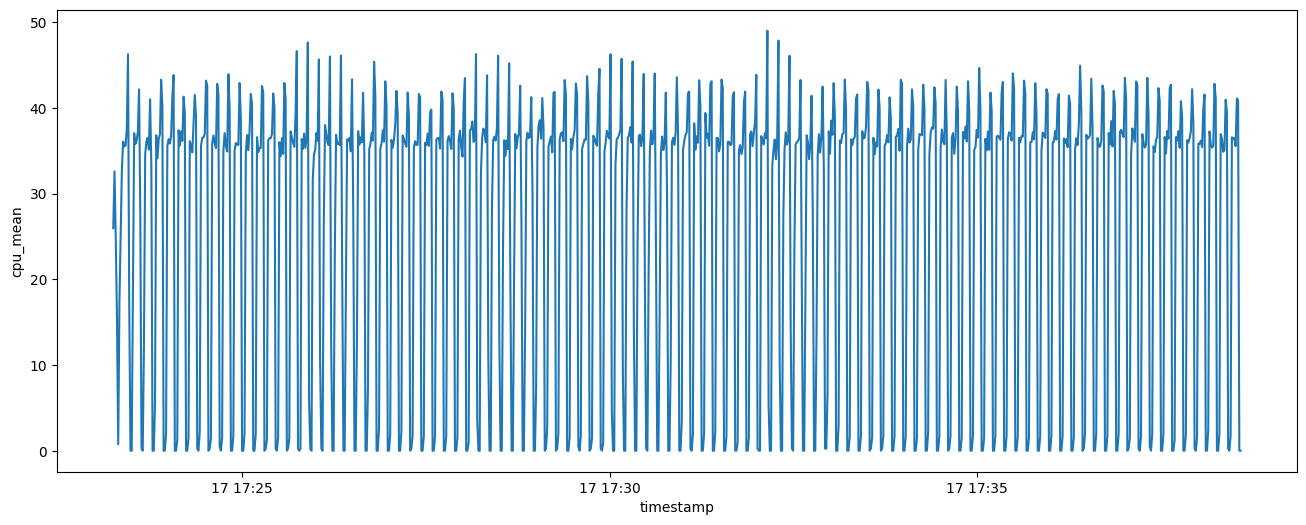

In [66]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

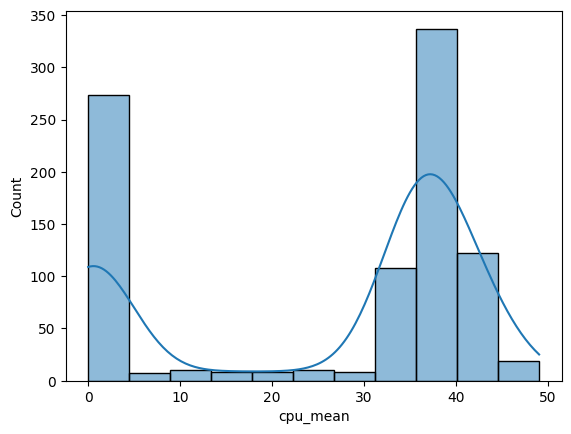

In [67]:
sns.histplot(data=dx22_cpu, x="cpu_mean", kde=True)
plt.show()

In [68]:
dx22_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,911,911.000000,911.000000,911.000000,911.000000,911.000000
mean,2026-04-17 17:30:54.318860,24.303293,27.089352,26.418441,24.326015,25.534276
min,2026-04-17 17:23:14.609670,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-17 17:27:04.380313,0.000000,0.000000,0.000000,0.000000,1.725000
50%,2026-04-17 17:30:53.840343,20.800000,25.500000,25.000000,21.600000,35.800000
75%,2026-04-17 17:34:43.955204,37.700000,43.600000,42.400000,38.100000,37.150000
max,2026-04-17 17:38:35.168794,91.900000,91.000000,92.100000,100.000000,49.025000
std,NaN,21.778822,23.478179,22.739804,21.588562,17.307429


### RAM

In [69]:
dx22_ram = pd.read_csv(f'{x22_folder_path}/mem.csv')
dx22_ram['timestamp'] = dx22_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:23:13.607824,17002643456,16381460480,621182976,3.7,15799484416,719716352,184123392,38420480,661766144
1,2026-04-17 17:23:14.609496,17002643456,16340500480,662142976,3.9,15755640832,752795648,185270272,38420480,664305664
2,2026-04-17 17:23:15.625407,17002643456,16269017088,733626368,4.3,15684157440,824918016,185270272,38420480,664305664
3,2026-04-17 17:23:16.636485,17002643456,16231563264,771080192,4.5,15646572544,850165760,185270272,38420480,664436736
4,2026-04-17 17:23:17.636946,17002643456,16090972160,911671296,5.4,15468019712,982319104,223232000,38420480,702726144


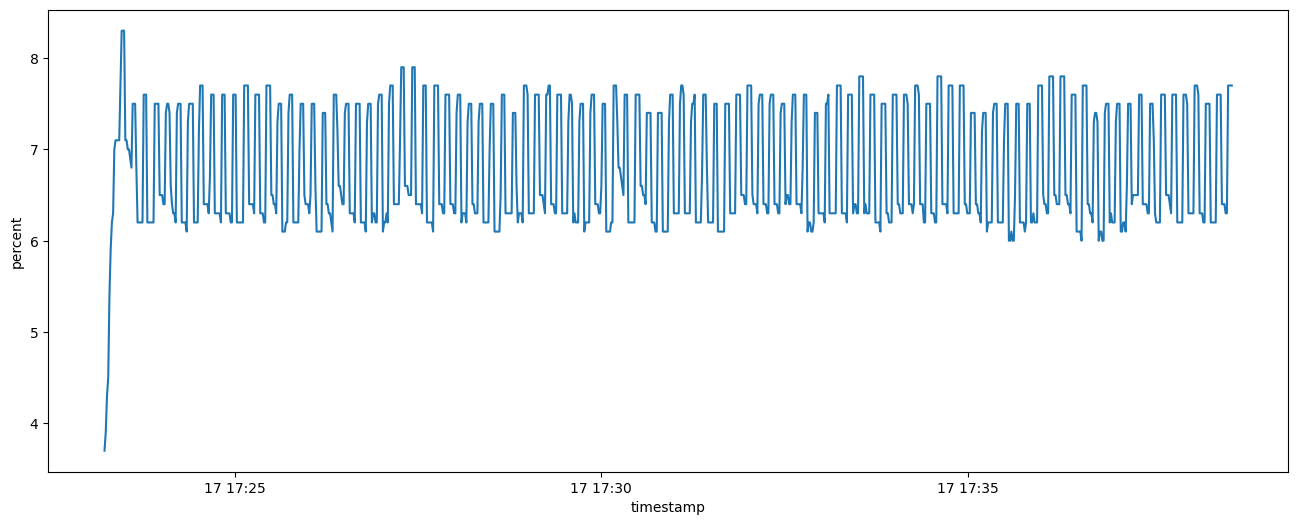

In [70]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

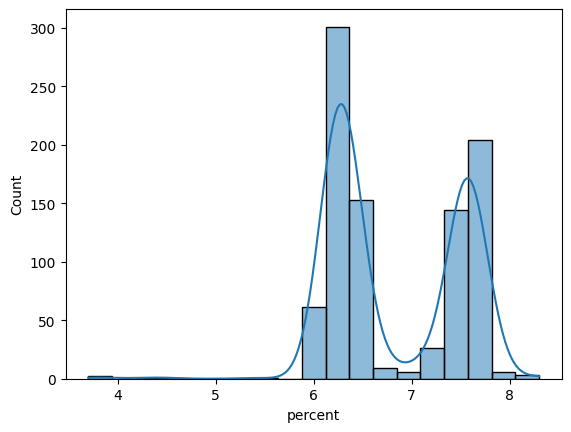

In [71]:
sns.histplot(data=dx22_ram, x="percent", kde=True)
plt.show()

In [72]:
dx22_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,918,9.180000e+02,9.180000e+02,9.180000e+02,918.000000,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02
mean,2026-04-17 17:30:54.325897,1.700264e+10,1.584317e+10,1.159473e+09,6.817974,1.509685e+10,1.292058e+09,3.427112e+08,3.851311e+07,8.257464e+08
min,2026-04-17 17:23:13.607824,1.700264e+10,1.559039e+10,6.211830e+08,3.700000,1.484328e+10,7.197164e+08,1.841234e+08,3.842048e+07,6.617661e+08
25%,2026-04-17 17:27:03.688167,1.700264e+10,1.572081e+10,1.063469e+09,6.300000,1.497362e+10,1.198686e+09,3.435233e+08,3.846963e+07,8.266220e+08
50%,2026-04-17 17:30:54.050247,1.700264e+10,1.590872e+10,1.093919e+09,6.400000,1.516129e+10,1.201848e+09,3.435233e+08,3.846963e+07,8.266220e+08
75%,2026-04-17 17:34:45.203597,1.700264e+10,1.593917e+10,1.281835e+09,7.500000,1.519201e+10,1.431421e+09,3.435397e+08,3.848602e+07,8.266220e+08
max,2026-04-17 17:38:36.161496,1.700264e+10,1.638146e+10,1.412252e+09,8.300000,1.579948e+10,1.437270e+09,3.439821e+08,3.892838e+07,8.269332e+08
std,NaN,0.000000e+00,1.133172e+08,1.133172e+08,0.666567,1.171029e+08,1.184573e+08,1.121407e+07,1.284345e+05,1.153321e+07


### Power

In [73]:
dx22_power = pd.read_csv(f'{x22_folder_path}/power.csv')
dx22_power['timestamp'] = dx22_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx22_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:23:03.372126,0.0,5.1099,0.76189,3.8856,2026-04-17 17:23:03.372126
1,2026-04-17T17:23:04.390572,1.0,5.1045,0.86995,4.4367,2026-04-17 17:23:04.390572
2,2026-04-17T17:23:05.367513,2.0,5.1097,0.79081,4.0331,2026-04-17 17:23:05.367513
3,2026-04-17T17:23:06.387981,3.0,5.1093,0.87220,4.4482,2026-04-17 17:23:06.387981
4,2026-04-17T17:23:07.363427,4.0,5.1089,0.79309,4.0447,2026-04-17 17:23:07.363427


In [74]:
dx22_power = dx22_power.sort_values('timestamp')

# Time difference in hours
dx22_power['dt_hours'] = dx22_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx22_power['energy_Wh'] = dx22_power['Power[W]'] * dx22_power['dt_hours']

# Total energy
total_energy_Wh = dx22_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.2854588055465
Total energy (kWh): 0.0012854588055465


In [75]:
dx22_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,936.000000,936.000000,936.000000,936.000000,936,935.000000,935.000000
mean,467.550962,5.109087,0.969477,4.947751,2026-04-17 17:30:50.921378,0.000278,0.001375
min,0.000000,5.091400,0.594620,3.038200,2026-04-17 17:23:03.372126,0.000269,0.000820
25%,233.750000,5.107600,0.747018,3.811875,2026-04-17 17:26:57.157292,0.000271,0.001079
50%,467.600000,5.109500,1.019705,5.205850,2026-04-17 17:30:50.921912,0.000283,0.001449
75%,701.350000,5.110800,1.116733,5.700350,2026-04-17 17:34:44.696437,0.000283,0.001583
max,935.100000,5.122800,1.504110,7.670900,2026-04-17 17:38:38.449525,0.000285,0.002176
std,270.387535,0.004418,0.210624,1.075021,NaN,0.000006,0.000300


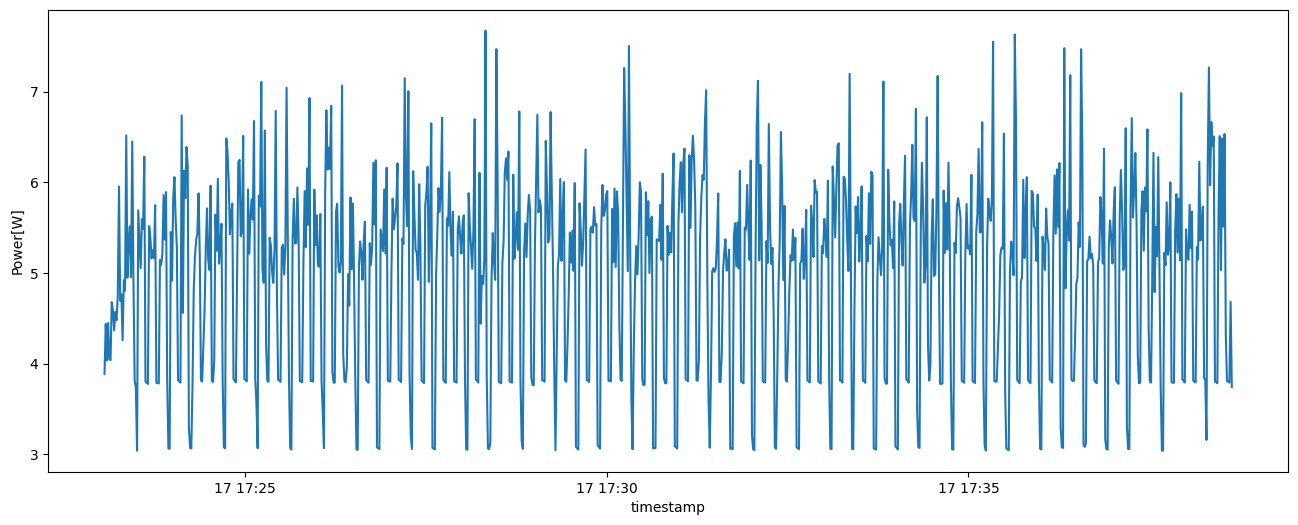

In [76]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.3

passage_time: 05; interval: 3; window: 1

In [77]:
x23_folder_path = '../infra/reports/batch_x23'

### Predict

In [78]:
from pandas import json_normalize
import json

with open(f'{x23_folder_path}/metrics.json') as f:
    x23_data = json.load(f)

load_model_duration = datetime.fromisoformat(x23_data['load_model_final']) - datetime.fromisoformat(x23_data['load_model_start'])
    
rows = []
for animal, v1 in x23_data['animals'].items():
    row = {
        'pid': x23_data['pid'],
        'load_model_start': datetime.fromisoformat(x23_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x23_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],       
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx23_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222


In [79]:
dx23_metrics_v0['by_animal_lead_time'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['first_image_capture_time']
dx23_metrics_v0['by_animal_processing_delay'] = dx23_metrics_v0['weight_prediction_final'] - dx23_metrics_v0['weight_prediction_start']
dx23_metrics_v0['by_animal_latency'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['last_image_capture_time']

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152


In [80]:
collect_lead_time = dx23_metrics_v0['display_time'].max() - dx23_metrics_v0['first_image_capture_time'].min()
qtt = len(dx23_metrics_v0['animal'].unique())

dx23_metrics_v0['collect_lead_time'] = collect_lead_time
dx23_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077,0 days 00:16:28.097418,364.336546
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549,0 days 00:16:28.097418,364.336546
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271,0 days 00:16:28.097418,364.336546
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539,0 days 00:16:28.097418,364.336546
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152,0 days 00:16:28.097418,364.336546


In [81]:
dx23_metrics_v0.describe()

,load_model_start,load_model_final,load_model_dur,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100,100,100,100,100,100.00,100.000000,100,100,100,100,100,100,1.000000e+02
mean,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:48:24.302942,2026-04-17 17:48:29.216736,2026-04-17 17:48:31.212248,5.99,1.760000,2026-04-17 17:48:30.193143,2026-04-17 17:48:31.212183,0 days 00:00:06.909305,0 days 00:00:01.019039,0 days 00:00:01.995511,0 days 00:16:28.097418,3.643365e+02
min,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5.00,1.000000,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.831709,0 days 00:00:01.802077,0 days 00:16:28.097418,3.643365e+02
25%,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:44:18.657442,2026-04-17 17:44:23.578121,2026-04-17 17:44:25.632422,6.00,2.000000,2026-04-17 17:44:24.551680,2026-04-17 17:44:25.632358,0 days 00:00:06.940671,0 days 00:00:01.065616,0 days 00:00:02.036826,0 days 00:16:28.097418,3.643365e+02
50%,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:48:24.165287,2026-04-17 17:48:29.080115,2026-04-17 17:48:31.013439,6.00,2.000000,2026-04-17 17:48:30.059284,2026-04-17 17:48:31.013375,0 days 00:00:06.960227,0 days 00:00:01.072188,0 days 00:00:02.047566,0 days 00:16:28.097418,3.643365e+02
75%,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:52:30.025344,2026-04-17 17:52:34.931259,2026-04-17 17:52:36.987154,6.00,2.000000,2026-04-17 17:52:35.907694,2026-04-17 17:52:36.987087,0 days 00:00:06.976052,0 days 00:00:01.081017,0 days 00:00:02.053530,0 days 00:16:28.097418,3.643365e+02
max,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2026-04-17 17:56:35.194746,2026-04-17 17:56:40.139886,2026-04-17 17:56:42.193635,6.00,2.000000,2026-04-17 17:56:41.109587,2026-04-17 17:56:42.193574,0 days 00:00:07.013703,0 days 00:00:01.097816,0 days 00:00:02.088859,0 days 00:16:28.097418,3.643365e+02
std,NaN,NaN,0 days 00:00:00,NaN,NaN,NaN,0.10,0.429235,NaN,NaN,0 days 00:00:00.139444,0 days 00:00:00.104033,0 days 00:00:00.100743,0 days 00:00:00,5.712979e-14


In [82]:
dx23_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:41.903925')

In [83]:
total_of_imgs = dx23_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx23_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 599 - Time: 0 days 00:16:28.097418 => FPS:0.606215530056167


### CPU

In [84]:
dx23_cpu = pd.read_csv(f'{x23_folder_path}/cpu.csv')

dx23_cpu['timestamp'] = dx23_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_cpu['cpu_mean']  = dx23_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx23_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:40:08.129732,1.0,3.0,95.0,2.0,25.250
1,2026-04-17 17:40:09.145478,11.0,40.8,63.0,10.0,31.200
2,2026-04-17 17:40:10.319013,0.9,81.2,17.5,0.9,25.125
3,2026-04-17 17:40:11.319525,1.0,0.0,37.6,0.0,9.650
4,2026-04-17 17:40:12.319928,0.0,0.0,4.0,1.0,1.250


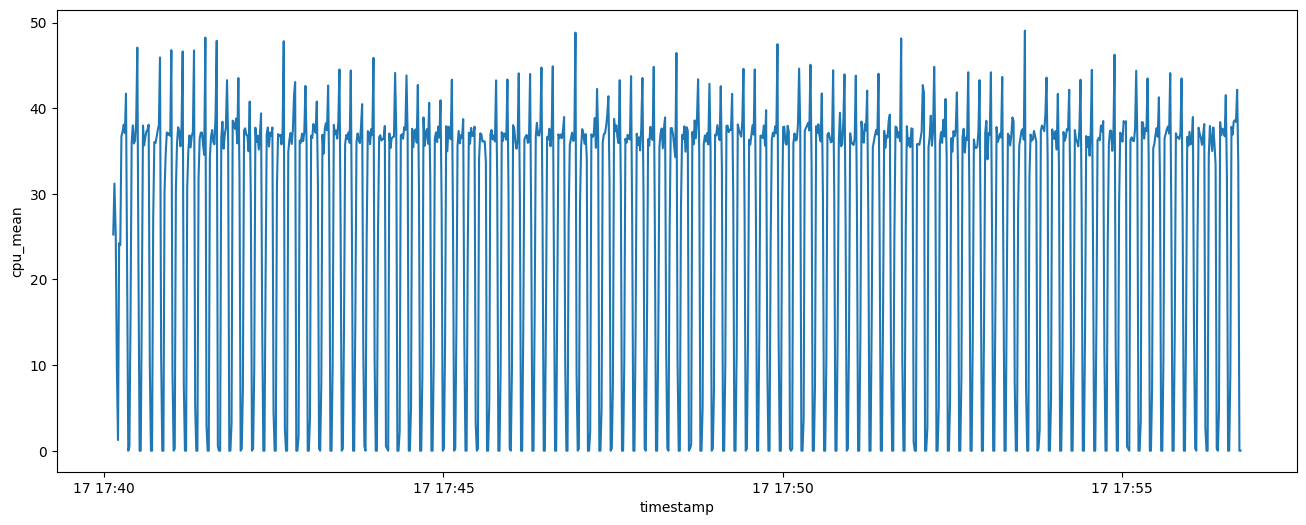

In [85]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

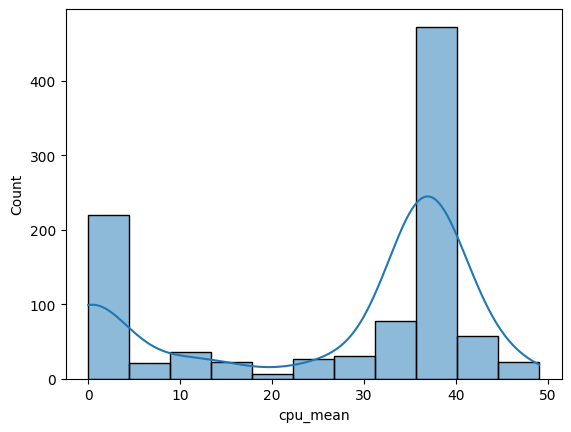

In [86]:
sns.histplot(data=dx23_cpu, x="cpu_mean", kde=True)
plt.show()

In [87]:
dx23_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,994,994.000000,994.000000,994.000000,994.000000,994.000000
mean,2026-04-17 17:48:26.428363,23.690040,28.871932,29.372535,24.061066,26.498893
min,2026-04-17 17:40:08.129732,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-17 17:44:17.487582,5.100000,6.100000,6.000000,6.025000,9.743750
50%,2026-04-17 17:48:26.372744,20.900000,26.250000,24.600000,22.000000,36.087500
75%,2026-04-17 17:52:35.496268,34.700000,44.600000,45.875000,35.375000,37.300000
max,2026-04-17 17:56:44.447713,90.000000,91.900000,97.000000,88.000000,49.050000
std,NaN,19.355075,23.076808,24.281167,19.351144,16.035689


### RAM

In [88]:
dx23_ram = pd.read_csv(f'{x23_folder_path}/mem.csv')
dx23_ram['timestamp'] = dx23_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:40:07.128923,17002643456,16404578304,598065152,3.5,15822569472,720044032,184516608,38420480,661749760
1,2026-04-17 17:40:08.129821,17002643456,16333815808,668827648,3.9,15748857856,756531200,185319424,38436864,664272896
2,2026-04-17 17:40:09.145592,17002643456,16282173440,720470016,4.2,15697215488,824082432,185319424,38436864,664272896
3,2026-04-17 17:40:10.166128,17002643456,16220372992,782270464,4.6,15635283968,862765056,185319424,38436864,664403968
4,2026-04-17 17:40:11.166486,17002643456,16079405056,923238400,5.4,15447244800,991363072,232390656,38436864,711868416


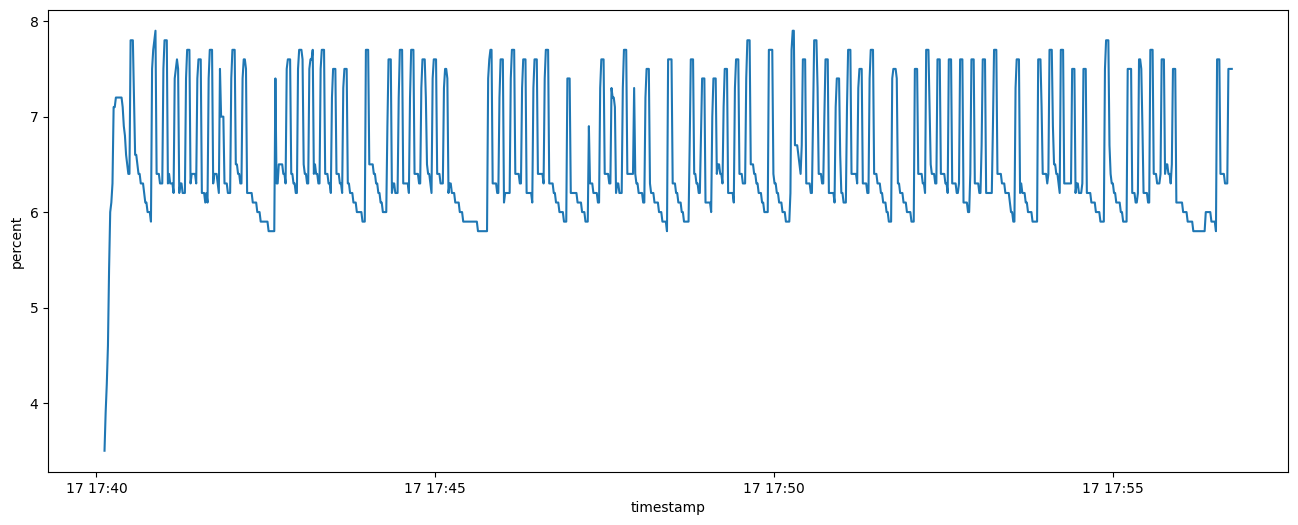

In [89]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

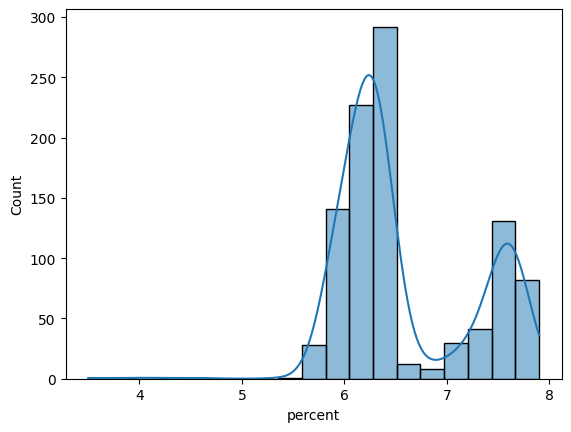

In [90]:
sns.histplot(data=dx23_ram, x="percent", kde=True)
plt.show()

In [91]:
dx23_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,997,9.970000e+02,9.970000e+02,9.970000e+02,997.00000,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02
mean,2026-04-17 17:48:26.247930,1.700264e+10,1.588490e+10,1.117741e+09,6.57342,1.513834e+10,1.261533e+09,3.428880e+08,3.856470e+07,8.258285e+08
min,2026-04-17 17:40:07.128923,1.700264e+10,1.565575e+10,5.980652e+08,3.50000,1.490849e+10,7.200440e+08,1.845166e+08,3.842048e+07,6.617498e+08
25%,2026-04-17 17:44:16.638504,1.700264e+10,1.576393e+10,1.043513e+09,6.10000,1.501664e+10,1.202749e+09,3.435889e+08,3.850240e+07,8.266056e+08
50%,2026-04-17 17:48:26.235852,1.700264e+10,1.592964e+10,1.073005e+09,6.30000,1.518233e+10,1.203716e+09,3.436052e+08,3.851878e+07,8.266056e+08
75%,2026-04-17 17:52:35.807356,1.700264e+10,1.595913e+10,1.238712e+09,7.30000,1.521182e+10,1.388642e+09,3.436052e+08,3.851878e+07,8.266056e+08
max,2026-04-17 17:56:45.407786,1.700264e+10,1.640458e+10,1.346896e+09,7.90000,1.582257e+10,1.437745e+09,3.440476e+08,3.896115e+07,8.268841e+08
std,NaN,0.000000e+00,1.109866e+08,1.109866e+08,0.65443,1.141987e+08,1.039854e+08,1.063222e+07,1.534324e+05,1.093728e+07


### Power

In [92]:
dx23_power = pd.read_csv(f'{x23_folder_path}/power.csv')
dx23_power['timestamp'] = dx23_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx23_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:39:56.343834,0.0,5.1097,0.71063,3.6242,2026-04-17 17:39:56.343834
1,2026-04-17T17:39:57.315169,1.0,5.1097,0.71011,3.6215,2026-04-17 17:39:57.315169
2,2026-04-17T17:39:58.331580,2.0,5.1100,0.82029,4.1916,2026-04-17 17:39:58.331580
3,2026-04-17T17:39:59.347140,3.0,5.1098,0.79178,4.0380,2026-04-17 17:39:59.347140
4,2026-04-17T17:40:00.317420,4.0,5.1098,0.86316,4.4021,2026-04-17 17:40:00.317420


In [93]:
dx23_power = dx23_power.sort_values('timestamp')

# Time difference in hours
dx23_power['dt_hours'] = dx23_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx23_power['energy_Wh'] = dx23_power['Power[W]'] * dx23_power['dt_hours']

# Total energy
total_energy_Wh = dx23_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.4217573599010276
Total energy (kWh): 0.0014217573599010277


In [94]:
dx23_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1015.000000,1015.000000,1015.000000,1015.000000,1015,1014.000000,1014.000000
mean,507.057537,5.109641,0.988373,5.045314,2026-04-17 17:48:23.385509,0.000278,0.001402
min,0.000000,5.092200,0.599710,3.064500,2026-04-17 17:39:56.343834,0.000269,0.000827
25%,253.500000,5.108450,0.752070,3.841350,2026-04-17 17:44:09.853000,0.000271,0.001085
50%,507.100000,5.110000,1.024830,5.231200,2026-04-17 17:48:23.378066,0.000283,0.001461
75%,760.600000,5.111300,1.125370,5.748000,2026-04-17 17:52:36.907037,0.000283,0.001586
max,1014.100000,5.126100,1.635720,8.342100,2026-04-17 17:56:50.458826,0.000285,0.002261
std,293.191903,0.004281,0.188822,0.963742,NaN,0.000006,0.000270


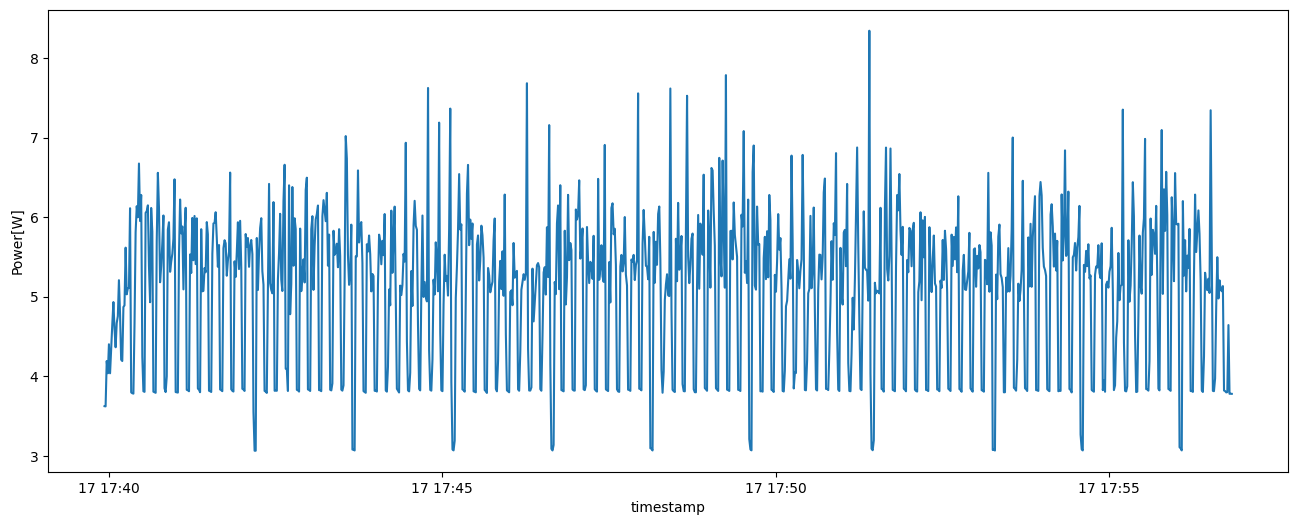

In [95]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X3.1 ~ Mas (Batch) | Baseline

passage_time: 10; interval: 3; window: 1; FPS: 1.0

In [96]:
x31_folder_path = '../infra/reports/mas-batch_baseline'

### Predict

In [97]:
from pandas import json_normalize
import json

with open(f'{x31_folder_path}/metrics.json') as f:
    x31_data = json.load(f)

load_model_duration = datetime.fromisoformat(x31_data['load_model_final']) - datetime.fromisoformat(x31_data['load_model_start'])
    
rows = []
for animal, v1 in x31_data['animals'].items():
    row = {
        'pid': x31_data['pid'],
        'load_model_start': datetime.fromisoformat(x31_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x31_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],       
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx31_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,1,2026-04-29 17:28:34.440846,2026-04-29 17:28:43.451687,2026-04-29 17:28:45.771054,10,3,2026-04-29 17:28:44.482224,2026-04-29 17:28:45.770939
1,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,2,2026-04-29 17:28:47.458004,2026-04-29 17:28:56.469412,2026-04-29 17:28:58.773115,10,3,2026-04-29 17:28:57.476519,2026-04-29 17:28:58.773007
2,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,3,2026-04-29 17:29:00.476040,2026-04-29 17:29:09.482449,2026-04-29 17:29:11.814904,10,3,2026-04-29 17:29:10.493416,2026-04-29 17:29:11.814799
3,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,4,2026-04-29 17:29:13.489341,2026-04-29 17:29:22.507228,2026-04-29 17:29:24.872300,10,3,2026-04-29 17:29:23.534483,2026-04-29 17:29:24.872191
4,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,5,2026-04-29 17:29:26.513029,2026-04-29 17:29:35.670518,2026-04-29 17:29:37.974113,10,3,2026-04-29 17:29:36.676985,2026-04-29 17:29:37.974015


In [98]:
dx31_metrics_v0['by_animal_lead_time'] = dx31_metrics_v0['display_time'] - dx31_metrics_v0['first_image_capture_time']
dx31_metrics_v0['by_animal_processing_delay'] = dx31_metrics_v0['weight_prediction_final'] - dx31_metrics_v0['weight_prediction_start']
dx31_metrics_v0['by_animal_latency'] = dx31_metrics_v0['display_time'] - dx31_metrics_v0['last_image_capture_time']

dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,1,2026-04-29 17:28:34.440846,2026-04-29 17:28:43.451687,2026-04-29 17:28:45.771054,10,3,2026-04-29 17:28:44.482224,2026-04-29 17:28:45.770939,0 days 00:00:11.330208,0 days 00:00:01.288715,0 days 00:00:02.319367
1,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,2,2026-04-29 17:28:47.458004,2026-04-29 17:28:56.469412,2026-04-29 17:28:58.773115,10,3,2026-04-29 17:28:57.476519,2026-04-29 17:28:58.773007,0 days 00:00:11.315111,0 days 00:00:01.296488,0 days 00:00:02.303703
2,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,3,2026-04-29 17:29:00.476040,2026-04-29 17:29:09.482449,2026-04-29 17:29:11.814904,10,3,2026-04-29 17:29:10.493416,2026-04-29 17:29:11.814799,0 days 00:00:11.338864,0 days 00:00:01.321383,0 days 00:00:02.332455
3,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,4,2026-04-29 17:29:13.489341,2026-04-29 17:29:22.507228,2026-04-29 17:29:24.872300,10,3,2026-04-29 17:29:23.534483,2026-04-29 17:29:24.872191,0 days 00:00:11.382959,0 days 00:00:01.337708,0 days 00:00:02.365072
4,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,5,2026-04-29 17:29:26.513029,2026-04-29 17:29:35.670518,2026-04-29 17:29:37.974113,10,3,2026-04-29 17:29:36.676985,2026-04-29 17:29:37.974015,0 days 00:00:11.461084,0 days 00:00:01.297030,0 days 00:00:02.303595


In [99]:
collect_lead_time = dx31_metrics_v0['display_time'].max() - dx31_metrics_v0['first_image_capture_time'].min()
qtt = len(dx31_metrics_v0['animal'].unique())

dx31_metrics_v0['collect_lead_time'] = collect_lead_time
dx31_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx31_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,1,2026-04-29 17:28:34.440846,2026-04-29 17:28:43.451687,2026-04-29 17:28:45.771054,10,3,2026-04-29 17:28:44.482224,2026-04-29 17:28:45.770939,0 days 00:00:11.330208,0 days 00:00:01.288715,0 days 00:00:02.319367,0 days 00:21:40.044168,276.913669
1,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,2,2026-04-29 17:28:47.458004,2026-04-29 17:28:56.469412,2026-04-29 17:28:58.773115,10,3,2026-04-29 17:28:57.476519,2026-04-29 17:28:58.773007,0 days 00:00:11.315111,0 days 00:00:01.296488,0 days 00:00:02.303703,0 days 00:21:40.044168,276.913669
2,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,3,2026-04-29 17:29:00.476040,2026-04-29 17:29:09.482449,2026-04-29 17:29:11.814904,10,3,2026-04-29 17:29:10.493416,2026-04-29 17:29:11.814799,0 days 00:00:11.338864,0 days 00:00:01.321383,0 days 00:00:02.332455,0 days 00:21:40.044168,276.913669
3,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,4,2026-04-29 17:29:13.489341,2026-04-29 17:29:22.507228,2026-04-29 17:29:24.872300,10,3,2026-04-29 17:29:23.534483,2026-04-29 17:29:24.872191,0 days 00:00:11.382959,0 days 00:00:01.337708,0 days 00:00:02.365072,0 days 00:21:40.044168,276.913669
4,mas-batch_2026-04-29T17:28:20.790342,2026-04-29 17:28:22.430977,2026-04-29 17:28:34.065719,0 days 00:00:11.634742,5,2026-04-29 17:29:26.513029,2026-04-29 17:29:35.670518,2026-04-29 17:29:37.974113,10,3,2026-04-29 17:29:36.676985,2026-04-29 17:29:37.974015,0 days 00:00:11.461084,0 days 00:00:01.297030,0 days 00:00:02.303595,0 days 00:21:40.044168,276.913669


In [100]:
dx31_metrics_v0[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,100.0,100.0,100,100,1.000000e+02
mean,10.0,3.0,0 days 00:00:01.285626,0 days 00:00:02.297291,2.769137e+02
std,0.0,0.0,0 days 00:00:00.021491,0 days 00:00:00.023191,5.712979e-14
min,10.0,3.0,0 days 00:00:01.250728,0 days 00:00:02.259544,2.769137e+02
25%,10.0,3.0,0 days 00:00:01.269000,0 days 00:00:02.280422,2.769137e+02
50%,10.0,3.0,0 days 00:00:01.280807,0 days 00:00:02.296698,2.769137e+02
75%,10.0,3.0,0 days 00:00:01.302303,0 days 00:00:02.312417,2.769137e+02
max,10.0,3.0,0 days 00:00:01.351684,0 days 00:00:02.365072,2.769137e+02


In [101]:
dx31_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:08.562688')

In [102]:
total_of_imgs = dx31_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx31_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 1000 - Time: 0 days 00:21:40.044168 => FPS:0.7692046352074402


### CPU

In [103]:
dx31_cpu = pd.read_csv(f'{x31_folder_path}/cpu.csv')

dx31_cpu['timestamp'] = dx31_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx31_cpu['cpu_mean']  = dx31_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx31_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-29 17:28:23.429934,38.0,33.0,41.5,16.8,32.325
1,2026-04-29 17:28:24.431105,54.5,37.0,20.0,19.8,32.825
2,2026-04-29 17:28:25.437374,38.8,38.6,45.0,41.4,40.950
3,2026-04-29 17:28:26.440552,52.6,57.7,7.0,10.0,31.825
4,2026-04-29 17:28:27.441373,72.1,70.0,1.0,1.0,36.025


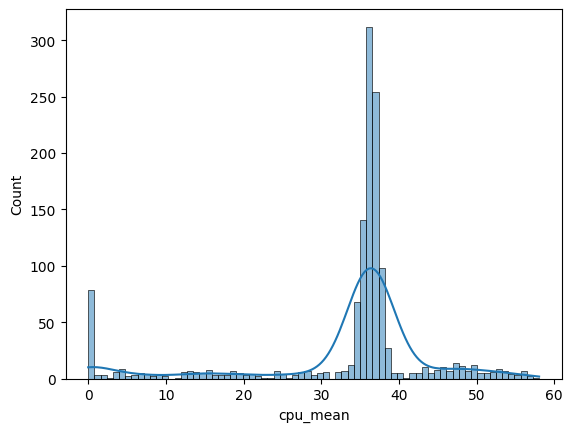

In [104]:
sns.histplot(data=dx31_cpu, x="cpu_mean", kde=True)
plt.show()

In [105]:
dx31_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1308,1308.000000,1308.000000,1308.000000,1308.000000,1308.000000
mean,2026-04-29 17:39:19.059764,33.285856,35.088456,34.269113,30.297477,33.235226
min,2026-04-29 17:28:23.429934,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-29 17:33:51.272558,21.200000,22.650000,21.600000,19.950000,35.112500
50%,2026-04-29 17:39:19.190602,33.000000,35.000000,34.700000,30.000000,36.250000
75%,2026-04-29 17:44:46.785972,45.500000,47.925000,46.150000,41.000000,37.200000
max,2026-04-29 17:50:14.544889,88.300000,84.700000,84.800000,81.600000,58.050000
std,NaN,17.727983,17.977862,18.045562,15.912488,11.988040


In [210]:
threshold = dx31_cpu['cpu_mean'].quantile(0.95)
dx31_cpu[dx31_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,65,65.000000,65.000000,65.000000,65.000000,65.000000
mean,2026-04-29 17:39:38.255199,53.447692,53.164615,50.580000,52.766154,52.489615
min,2026-04-29 17:28:45.625773,39.600000,37.400000,38.400000,39.400000,48.975000
25%,2026-04-29 17:35:02.724125,47.400000,48.500000,44.400000,47.100000,50.150000
50%,2026-04-29 17:38:31.541115,52.000000,52.900000,51.000000,53.100000,52.600000
75%,2026-04-29 17:45:14.604140,57.400000,57.700000,55.900000,57.700000,54.275000
max,2026-04-29 17:48:56.352978,77.600000,71.000000,68.700000,69.700000,58.050000
std,NaN,9.320208,7.705242,7.105284,6.832466,2.462519


### RAM

In [107]:
dx31_ram = pd.read_csv(f'{x31_folder_path}/mem.csv')
dx31_ram['timestamp'] = dx31_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx31_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-29 17:28:22.429093,17002643456,16270884864,731758592,4.3,15658696704,767377408,208846848,42450944,689078272
1,2026-04-29 17:28:23.429644,17002643456,16250716160,751927296,4.4,15635939328,800538624,209502208,42565632,691290112
2,2026-04-29 17:28:24.430861,17002643456,16212803584,789839872,4.6,15598026752,840663040,209502208,42565632,691290112
3,2026-04-29 17:28:25.435152,17002643456,16121430016,881213440,5.2,15506653184,929824768,209502208,42565632,691290112
4,2026-04-29 17:28:26.435477,17002643456,16112222208,890421248,5.2,15497314304,936886272,209502208,42565632,691421184


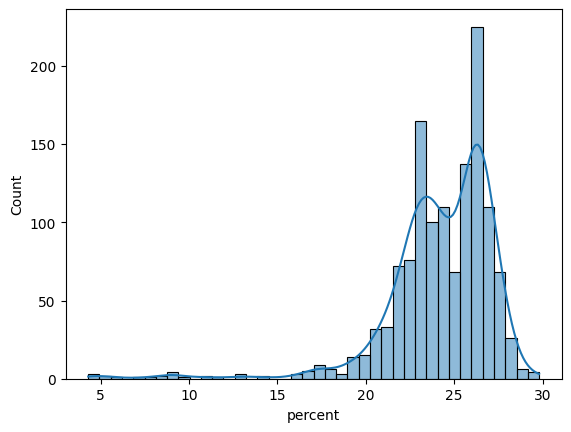

In [108]:
sns.histplot(data=dx31_ram, x="percent", kde=True)
plt.show()

In [109]:
dx31_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1310,1.310000e+03,1.310000e+03,1.310000e+03,1310.000000,1.310000e+03,1.310000e+03,1.310000e+03,1.310000e+03,1.310000e+03
mean,2026-04-29 17:39:18.614224,1.700264e+10,1.288204e+10,4.120607e+09,24.234046,1.210540e+10,4.259100e+09,3.672892e+08,4.277292e+07,8.530533e+08
min,2026-04-29 17:28:22.429093,1.700264e+10,1.193940e+10,7.317586e+08,4.300000,1.116157e+10,7.673774e+08,2.088468e+08,4.245094e+07,6.890783e+08
25%,2026-04-29 17:33:50.661124,1.700264e+10,1.252120e+10,3.898294e+09,22.900000,1.174354e+10,4.045734e+09,3.680502e+08,4.264755e+07,8.539505e+08
50%,2026-04-29 17:39:18.587246,1.700264e+10,1.283026e+10,4.172382e+09,24.500000,1.205282e+10,4.330062e+09,3.680666e+08,4.266394e+07,8.539505e+08
75%,2026-04-29 17:44:46.515921,1.700264e+10,1.310435e+10,4.481446e+09,26.400000,1.232693e+10,4.640535e+09,3.684065e+08,4.300390e+07,8.540488e+08
max,2026-04-29 17:50:14.617525,1.700264e+10,1.627088e+10,5.063246e+09,29.800000,1.565870e+10,5.218091e+09,3.684106e+08,4.300800e+07,8.541143e+08
std,NaN,0.000000e+00,5.246305e+08,5.246305e+08,3.087442,5.305027e+08,5.541087e+08,1.150642e+07,1.665014e+05,1.182362e+07


In [211]:
threshold = dx31_ram['percent'].quantile(0.95)
dx31_ram[dx31_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,62,6.200000e+01,6.200000e+01,6.200000e+01,62.000000,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01
mean,2026-04-29 17:43:21.248636,1.700264e+10,1.222700e+10,4.775646e+09,28.088710,1.144924e+10,4.900741e+09,3.683448e+08,4.294220e+07,8.540340e+08
min,2026-04-29 17:37:39.892783,1.700264e+10,1.193940e+10,4.684972e+09,27.600000,1.116157e+10,4.758225e+09,3.680666e+08,4.266394e+07,8.539505e+08
25%,2026-04-29 17:43:22.837393,1.700264e+10,1.219807e+10,4.715028e+09,27.700000,1.142026e+10,4.861121e+09,3.683942e+08,4.299162e+07,8.540488e+08
50%,2026-04-29 17:43:38.123594,1.700264e+10,1.225662e+10,4.746019e+09,27.900000,1.147880e+10,4.890812e+09,3.683942e+08,4.299162e+07,8.540488e+08
75%,2026-04-29 17:44:04.429807,1.700264e+10,1.228761e+10,4.804571e+09,28.275000,1.150980e+10,4.949512e+09,3.683942e+08,4.299162e+07,8.540488e+08
max,2026-04-29 17:50:14.617525,1.700264e+10,1.231767e+10,5.063246e+09,29.800000,1.153986e+10,5.218091e+09,3.684106e+08,4.300800e+07,8.541143e+08
std,NaN,0.000000e+00,9.151727e+07,9.151727e+07,0.539309,9.156762e+07,9.556881e+07,1.231971e+05,1.231971e+05,3.784223e+04


### Power

In [111]:
dx31_power = pd.read_csv(f'{x31_folder_path}/power.csv')
dx31_power['timestamp'] = dx31_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx31_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-29T17:28:10.280121,0.0,5.1094,0.70376,3.5891,2026-04-29 17:28:10.280121
1,2026-04-29T17:28:11.299385,1.0,5.1095,0.81261,4.1443,2026-04-29 17:28:11.299385
2,2026-04-29T17:28:12.272362,2.0,5.1096,0.78295,3.9930,2026-04-29 17:28:12.272362
3,2026-04-29T17:28:13.288137,3.0,5.1098,0.78336,3.9951,2026-04-29 17:28:13.288137
4,2026-04-29T17:28:14.305189,4.0,5.1098,0.80104,4.0853,2026-04-29 17:28:14.305189


In [112]:
dx31_power = dx31_power.sort_values('timestamp')

# Time difference in hours
dx31_power['dt_hours'] = dx31_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx31_power['energy_Wh'] = dx31_power['Power[W]'] * dx31_power['dt_hours']

# Total energy
total_energy_Wh = dx31_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 2.035459595028639
Total energy (kWh): 0.002035459595028639


In [113]:
dx31_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1328.000000,1328.000000,1328.000000,1328.000000,1328,1327.000000,1327.000000
mean,663.620105,5.107382,1.081805,5.519305,2026-04-29 17:39:13.918232,0.000278,0.001534
min,0.000000,5.073600,0.597440,3.046900,2026-04-29 17:28:10.280121,0.000269,0.000827
25%,331.850000,5.104700,1.014438,5.174550,2026-04-29 17:33:42.097460,0.000271,0.001430
50%,663.600000,5.108100,1.089620,5.555800,2026-04-29 17:39:13.920620,0.000283,0.001544
75%,995.450000,5.110500,1.176235,6.004350,2026-04-29 17:44:45.715944,0.000284,0.001670
max,1327.300000,5.122700,1.794490,9.133900,2026-04-29 17:50:17.532073,0.000286,0.002595
std,383.576139,0.005357,0.169604,0.865465,NaN,0.000006,0.000243


## X4.0 ~ Mas (Single) | Baseline

passage_time: 10; interval: 3; window: 3

In [114]:
x40_folder_path = '../infra/reports/mas-single_baseline'

### Predict

In [182]:
from pandas import json_normalize
import json

with open(f'{x40_folder_path}/metrics.json') as f:
    x40_data = json.load(f)

load_model_duration = datetime.fromisoformat(x40_data['load_model_final']) - datetime.fromisoformat(x40_data['load_model_start'])
    
rows = []
for animal, v1 in x40_data['animals'].items():
    row_base = {
        'pid': x40_data['pid'],
        'load_model_start': datetime.fromisoformat(x40_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x40_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images': v1['total_of_images'],
        'suitable_images': v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        row = row_base.copy()
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx40_metrics_v0 = pd.DataFrame.from_dict(rows)
dx40_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:00.215576,2026-04-29 17:04:02.675351
1,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:02.136581,2026-04-29 17:04:06.356653
2,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:04.238151,2026-04-29 17:04:09.336072
3,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:12.799375,2026-04-29 17:04:15.027052
4,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:15.079964,2026-04-29 17:04:18.748241


In [183]:
dx40_metrics_v0['img_weight_prediction_dur'] = dx40_metrics_v0['weight_prediction_final'] - dx40_metrics_v0['weight_prediction_start']
dx40_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur
0,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:00.215576,2026-04-29 17:04:02.675351,0 days 00:00:02.459775
1,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:02.136581,2026-04-29 17:04:06.356653,0 days 00:00:04.220072
2,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:04.238151,2026-04-29 17:04:09.336072,0 days 00:00:05.097921
3,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:12.799375,2026-04-29 17:04:15.027052,0 days 00:00:02.227677
4,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:15.079964,2026-04-29 17:04:18.748241,0 days 00:00:03.668277


In [184]:
by_animal_dict = []

for animal, by_animal in dx40_metrics_v0.groupby('animal'):
    # .max() return the most recent date   
    by_animal_lead_time = by_animal['display_time'].max() - by_animal['first_image_capture_time'].iloc[0]
    by_animal_processing_delay = by_animal['img_weight_prediction_dur'].sum()
    by_animal_latency = by_animal['display_time'].max() - by_animal['last_image_capture_time'].max()
    
    by_animal_dict.append({
        'animal': animal,
        'by_animal_lead_time':by_animal_lead_time,
        'by_animal_processing_delay':by_animal_processing_delay,
        'by_animal_latency':by_animal_latency,
    })

dx40_metrics_v1 = dx40_metrics_v0.merge(
    pd.DataFrame.from_records(by_animal_dict),
    on='animal'
)
dx40_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:00.215576,2026-04-29 17:04:02.675351,0 days 00:00:02.459775,0 days 00:00:11.714805,0 days 00:00:11.777768,0 days 00:00:02.691794
1,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:02.136581,2026-04-29 17:04:06.356653,0 days 00:00:04.220072,0 days 00:00:11.714805,0 days 00:00:11.777768,0 days 00:00:02.691794
2,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:04.238151,2026-04-29 17:04:09.336072,0 days 00:00:05.097921,0 days 00:00:11.714805,0 days 00:00:11.777768,0 days 00:00:02.691794
3,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:12.799375,2026-04-29 17:04:15.027052,0 days 00:00:02.227677,0 days 00:00:11.424418,0 days 00:00:10.543058,0 days 00:00:02.407358
4,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:15.079964,2026-04-29 17:04:18.748241,0 days 00:00:03.668277,0 days 00:00:11.424418,0 days 00:00:10.543058,0 days 00:00:02.407358


In [186]:
collect_lead_time = dx40_metrics_v1['display_time'].max() - dx40_metrics_v1['first_image_capture_time'].min()
qtt = len(dx40_metrics_v1['animal'].unique())

dx40_metrics_v1['collect_lead_time'] = collect_lead_time
dx40_metrics_v1['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx40_metrics_v1.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,img_weight_prediction_dur,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:00.215576,2026-04-29 17:04:02.675351,0 days 00:00:02.459775,0 days 00:00:11.714805,0 days 00:00:11.777768,0 days 00:00:02.691794,0 days 00:21:41.206124,276.666389
1,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:02.136581,2026-04-29 17:04:06.356653,0 days 00:00:04.220072,0 days 00:00:11.714805,0 days 00:00:11.777768,0 days 00:00:02.691794,0 days 00:21:41.206124,276.666389
2,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,1,2026-04-29 17:03:58.783946,2026-04-29 17:04:07.806957,2026-04-29 17:04:10.498751,10,3,2026-04-29 17:04:04.238151,2026-04-29 17:04:09.336072,0 days 00:00:05.097921,0 days 00:00:11.714805,0 days 00:00:11.777768,0 days 00:00:02.691794,0 days 00:21:41.206124,276.666389
3,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:12.799375,2026-04-29 17:04:15.027052,0 days 00:00:02.227677,0 days 00:00:11.424418,0 days 00:00:10.543058,0 days 00:00:02.407358,0 days 00:21:41.206124,276.666389
4,mas-single_2026-04-29T17:03:46.193421,2026-04-29 17:03:47.771659,2026-04-29 17:03:58.759961,0 days 00:00:10.988302,2,2026-04-29 17:04:11.812304,2026-04-29 17:04:20.829364,2026-04-29 17:04:23.236722,10,3,2026-04-29 17:04:15.079964,2026-04-29 17:04:18.748241,0 days 00:00:03.668277,0 days 00:00:11.424418,0 days 00:00:10.543058,0 days 00:00:02.407358,0 days 00:21:41.206124,276.666389


In [187]:
dx40_metrics_v1[['total_of_images', 'suitable_images', 'by_animal_processing_delay', 'by_animal_latency', 'mean_throughput']].describe()

,total_of_images,suitable_images,by_animal_processing_delay,by_animal_latency,mean_throughput
count,300.0,300.0,300,300,3.000000e+02
mean,10.0,3.0,0 days 00:00:10.790191,0 days 00:00:02.493850,2.766664e+02
std,0.0,0.0,0 days 00:00:00.324328,0 days 00:00:00.088856,5.693840e-14
min,10.0,3.0,0 days 00:00:10.241075,0 days 00:00:02.369469,2.766664e+02
25%,10.0,3.0,0 days 00:00:10.538133,0 days 00:00:02.439263,2.766664e+02
50%,10.0,3.0,0 days 00:00:10.756842,0 days 00:00:02.475034,2.766664e+02
75%,10.0,3.0,0 days 00:00:10.975366,0 days 00:00:02.526788,2.766664e+02
max,10.0,3.0,0 days 00:00:11.777768,0 days 00:00:02.989529,2.766664e+02


In [191]:
dx40_metrics_v1.groupby('animal')['by_animal_processing_delay'].mean().reset_index(name='time')['time'].sum()

Timedelta('0 days 00:17:59.019142')

In [192]:
total_of_imgs = dx40_metrics_v1.groupby('animal')['total_of_images'].mean().reset_index(name='qtd')['qtd'].sum()
total_time = pd.to_timedelta(dx40_metrics_v1['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 1000.0 - Time: 0 days 00:21:41.206124 => FPS:0.7685177479229263


### CPU

In [122]:
dx40_cpu = pd.read_csv(f'{x40_folder_path}/cpu.csv')

dx40_cpu['timestamp'] = dx40_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx40_cpu['cpu_mean']  = dx40_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx40_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-29 17:03:48.776302,57.0,17.8,5.0,45.4,31.300
1,2026-04-29 17:03:49.783473,26.3,28.3,33.0,46.5,33.525
2,2026-04-29 17:03:50.790092,35.4,44.0,35.0,50.0,41.100
3,2026-04-29 17:03:51.790881,32.7,3.0,31.4,59.2,31.575
4,2026-04-29 17:03:52.791793,70.4,0.0,0.0,71.0,35.350


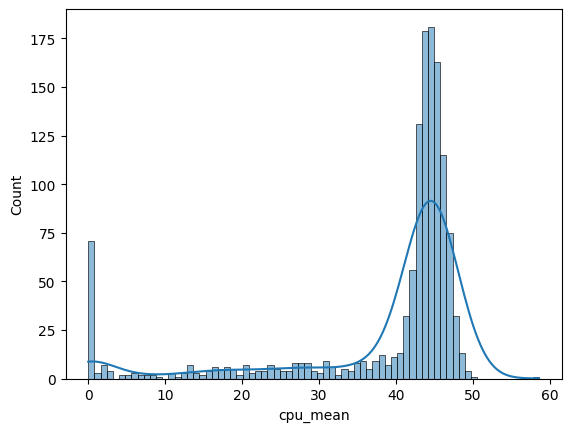

In [123]:
sns.histplot(data=dx40_cpu, x="cpu_mean", kde=True)
plt.show()

In [124]:
dx40_cpu.describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1298,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000
mean,2026-04-29 17:14:44.448526,38.650924,38.795069,38.804006,38.384129,38.658532
min,2026-04-29 17:03:48.776302,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-04-29 17:09:16.587433,37.400000,37.600000,37.800000,37.400000,41.256250
50%,2026-04-29 17:14:44.430654,42.100000,42.900000,42.800000,42.200000,43.950000
75%,2026-04-29 17:20:12.264216,46.000000,46.675000,46.500000,45.500000,45.400000
max,2026-04-29 17:25:40.038802,70.400000,77.800000,76.500000,75.500000,58.625000
std,NaN,14.165720,14.782973,14.755979,14.180408,12.924708


In [212]:
threshold = dx40_cpu['cpu_mean'].quantile(0.95)
dx40_cpu[dx40_cpu['cpu_mean'] > threshold].describe()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,62,62.000000,62.000000,62.000000,62.000000,62.000000
mean,2026-04-29 17:14:11.805810,47.303226,48.491935,48.554839,48.211290,48.140323
min,2026-04-29 17:04:05.027271,40.800000,41.800000,40.400000,40.400000,47.275000
25%,2026-04-29 17:09:09.069270,44.600000,45.425000,45.000000,44.925000,47.456250
50%,2026-04-29 17:13:49.816012,46.000000,47.250000,47.500000,46.800000,47.812500
75%,2026-04-29 17:19:58.329544,47.900000,49.500000,52.525000,49.500000,48.250000
max,2026-04-29 17:25:08.705818,58.300000,59.800000,58.000000,75.500000,58.625000
std,NaN,4.373128,4.596481,4.531336,5.526304,1.495063


### RAM

In [126]:
dx40_ram = pd.read_csv(f'{x40_folder_path}/mem.csv')
dx40_ram['timestamp'] = dx40_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx40_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-29 17:03:47.769780,17002643456,16302489600,700153856,4.1,15689940992,771981312,208994304,42549248,689045504
1,2026-04-29 17:03:48.776374,17002643456,16215080960,787562496,4.6,15600205824,801341440,209616896,42680320,691257344
2,2026-04-29 17:03:49.783634,17002643456,16156442624,846200832,5.0,15541567488,840957952,209616896,42680320,691257344
3,2026-04-29 17:03:50.785511,17002643456,16062578688,940064768,5.5,15447703552,938262528,209616896,42680320,691257344
4,2026-04-29 17:03:51.785861,17002643456,16055582720,947060736,5.6,15440576512,940179456,209616896,42680320,691388416


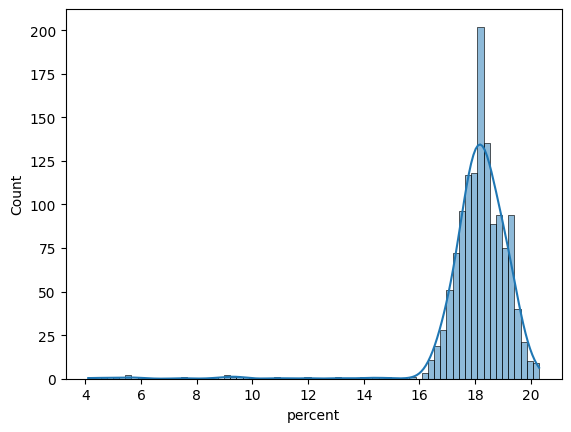

In [127]:
sns.histplot(data=dx40_ram, x="percent", kde=True)
plt.show()

In [128]:
dx40_ram.describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,1304,1.304000e+03,1.304000e+03,1.304000e+03,1304.000000,1.304000e+03,1.304000e+03,1.304000e+03,1.304000e+03,1.304000e+03
mean,2026-04-29 17:14:44.007110,1.700264e+10,1.392287e+10,3.079774e+09,18.113497,1.312771e+10,3.222530e+09,3.676758e+08,4.293308e+07,8.714545e+08
min,2026-04-29 17:03:47.769780,1.700264e+10,1.354531e+10,7.001539e+08,4.100000,1.269455e+10,7.719813e+08,2.089943e+08,4.254925e+07,6.890455e+08
25%,2026-04-29 17:09:15.933460,1.700264e+10,1.380578e+10,3.011514e+09,17.700000,1.300437e+10,3.134501e+09,3.681812e+08,4.271309e+07,8.538522e+08
50%,2026-04-29 17:14:44.007231,1.700264e+10,1.390567e+10,3.096969e+09,18.200000,1.311024e+10,3.244499e+09,3.681976e+08,4.272947e+07,8.538685e+08
75%,2026-04-29 17:20:12.024258,1.700264e+10,1.399113e+10,3.196862e+09,18.800000,1.321360e+10,3.356946e+09,3.693117e+08,4.335206e+07,9.267446e+08
max,2026-04-29 17:25:40.257489,1.700264e+10,1.630249e+10,3.457335e+09,20.300000,1.568994e+10,3.627876e+09,3.693445e+08,4.338483e+07,9.268593e+08
std,NaN,0.000000e+00,2.375285e+08,2.375285e+08,1.395872,2.564359e+08,2.671069e+08,1.134928e+07,2.821590e+05,3.424563e+07


In [215]:
threshold = dx40_ram['percent'].quantile(0.95)
dx40_ram[dx40_ram['percent'] > threshold].describe()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
count,56,5.600000e+01,5.600000e+01,5.600000e+01,56.000000,5.600000e+01,5.600000e+01,5.600000e+01,5.600000e+01,5.600000e+01
mean,2026-04-29 17:18:25.773956,1.700264e+10,1.363347e+10,3.369177e+09,19.808929,1.282195e+10,3.509058e+09,3.687670e+08,4.306856e+07,8.877220e+08
min,2026-04-29 17:06:32.960766,1.700264e+10,1.354531e+10,3.324379e+09,19.600000,1.269455e+10,3.365700e+09,3.681812e+08,4.271309e+07,8.538358e+08
25%,2026-04-29 17:15:51.716528,1.700264e+10,1.360689e+10,3.339047e+09,19.600000,1.280287e+10,3.473740e+09,3.681976e+08,4.272947e+07,8.538685e+08
50%,2026-04-29 17:19:29.027691,1.700264e+10,1.364630e+10,3.356344e+09,19.700000,1.282369e+10,3.507282e+09,3.685581e+08,4.307354e+07,8.539996e+08
75%,2026-04-29 17:23:24.683428,1.700264e+10,1.366360e+10,3.395756e+09,20.000000,1.285255e+10,3.558199e+09,3.693281e+08,4.336845e+07,9.267610e+08
max,2026-04-29 17:25:35.216765,1.700264e+10,1.367826e+10,3.457335e+09,20.300000,1.289998e+10,3.627876e+09,3.693445e+08,4.338483e+07,9.267610e+08
std,NaN,0.000000e+00,3.664229e+07,3.664229e+07,0.208263,4.645922e+07,6.604491e+07,5.446451e+05,3.067700e+05,3.667105e+07


### Power

In [130]:
dx40_power = pd.read_csv(f'{x40_folder_path}/power.csv')
dx40_power['timestamp'] = dx40_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx40_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-29T17:03:35.978608,0.0,5.1100,0.55132,2.8172,2026-04-29 17:03:35.978608
1,2026-04-29T17:03:36.947992,1.0,5.1100,0.75854,3.8761,2026-04-29 17:03:36.947992
2,2026-04-29T17:03:37.965638,2.0,5.1098,0.77257,3.9401,2026-04-29 17:03:37.965638
3,2026-04-29T17:03:38.985578,3.0,5.1094,0.86681,4.4207,2026-04-29 17:03:38.985578
4,2026-04-29T17:03:39.959582,4.0,5.1091,0.77434,3.9491,2026-04-29 17:03:39.959582


In [131]:
dx40_power = dx40_power.sort_values('timestamp')

# Time difference in hours
dx40_power['dt_hours'] = dx40_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx40_power['energy_Wh'] = dx40_power['Power[W]'] * dx40_power['dt_hours']

# Total energy
total_energy_Wh = dx40_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 2.1136197418966667
Total energy (kWh): 0.0021136197418966667


In [132]:
dx40_power.describe()

,Time[S],Volt[V],Current[A],Power[W],timestamp,dt_hours,energy_Wh
count,1329.000000,1329.000000,1329.000000,1329.000000,1329,1328.000000,1328.000000
mean,664.120015,5.107232,1.122393,5.726142,2026-04-29 17:14:40.092026,0.000278,0.001592
min,0.000000,5.078100,0.551320,2.817200,2026-04-29 17:03:35.978608,0.000269,0.000892
25%,332.100000,5.104500,1.057320,5.397900,2026-04-29 17:09:08.049146,0.000271,0.001497
50%,664.100000,5.107800,1.144140,5.838000,2026-04-29 17:14:40.081499,0.000283,0.001621
75%,996.200000,5.110300,1.227700,6.262600,2026-04-29 17:20:12.172025,0.000284,0.001745
max,1328.300000,5.131700,1.579900,8.057400,2026-04-29 17:25:44.224389,0.000285,0.002261
std,383.863307,0.005736,0.169422,0.863845,NaN,0.000006,0.000243


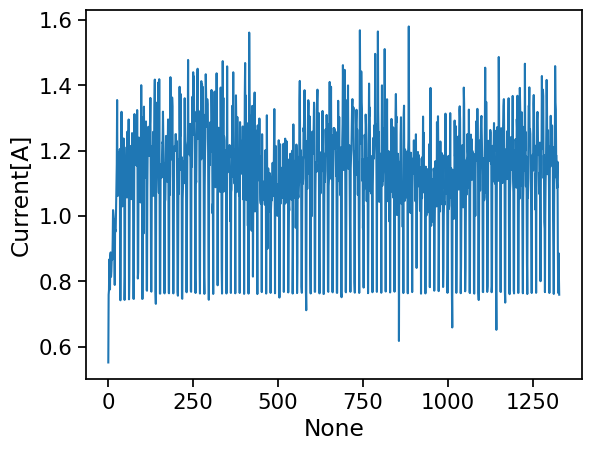

In [245]:
ax = sns.lineplot(data=dx40_power, x=dx40_power.index, y="Current[A]")

# Charts

In [229]:
sns.set_context("notebook", font_scale=1.4)
window_size = 30

## CPU

In [230]:
dx10_cpu_w = dx10_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx10_cpu_w['arch-str'] = 'SEQ-S'
dx10_cpu_w.shape

(45, 2)

In [231]:
dx20_cpu_w = dx20_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx20_cpu_w['arch-str'] = 'SEQ-B'
dx20_cpu_w.shape

(50, 2)

In [232]:
dx30_cpu_w = dx31_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx30_cpu_w['arch-str'] = 'MAS-B'
dx30_cpu_w.shape

(43, 2)

In [233]:
dx40_cpu_w = dx40_cpu[['cpu_mean']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx40_cpu_w['arch-str'] = 'MAS-S'
dx40_cpu_w.shape

(42, 2)

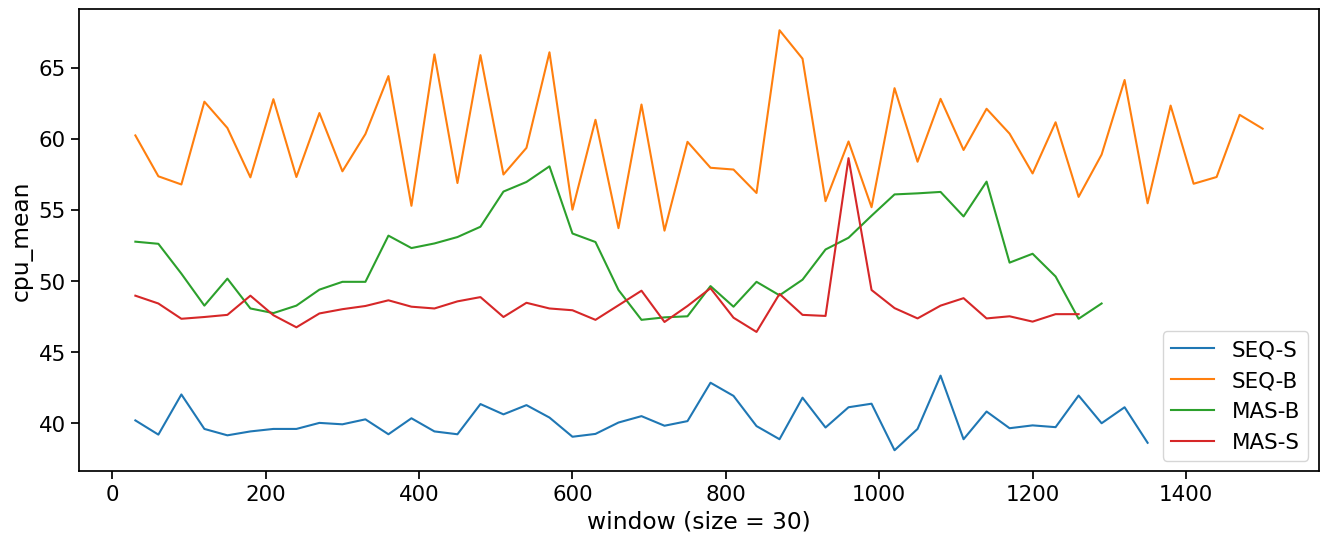

In [237]:
dall_cpu = pd.concat([dx10_cpu_w, dx20_cpu_w, dx30_cpu_w, dx40_cpu_w])
dall_cpu.sort_index().head()

plt.figure(figsize=(16, 6))

ax = sns.lineplot(data=dall_cpu, x=dall_cpu.index, y="cpu_mean", hue='arch-str', )
ax.legend().set_title('')
ax.set_xlabel(f'window (size = {window_size})')

# Save with 600 DPI
plt.savefig("output/cpu-mean-chart.pdf", format="pdf", dpi=600, bbox_inches="tight")

## RAM

In [238]:
dx10_ram_w = dx10_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx10_ram_w['arch-str'] = 'SEQ-S'
dx10_ram_w.shape

(45, 2)

In [239]:
dx20_ram_w = dx20_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx20_ram_w['arch-str'] = 'SEQ-B'
dx20_ram_w.shape

(50, 2)

In [240]:
dx30_ram_w = dx31_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx30_ram_w['arch-str'] = 'MAS-B'
dx30_ram_w.shape

(43, 2)

In [241]:
dx40_ram_w = dx40_ram[['percent']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx40_ram_w['arch-str'] = 'MAS-S'
dx40_ram_w.shape

(42, 2)

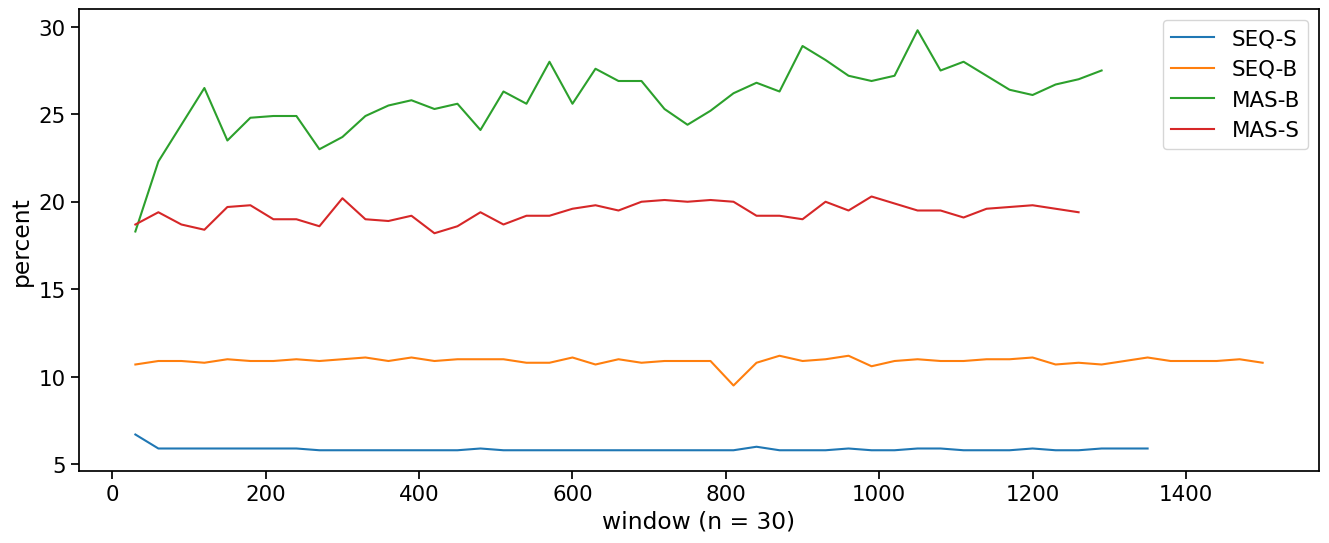

In [242]:
dall_ram = pd.concat([dx10_ram_w, dx20_ram_w, dx30_ram_w, dx40_ram_w])
dall_ram.sort_index().head()

plt.figure(figsize=(16, 6))

ax = sns.lineplot(data=dall_ram, x=dall_ram.index, y="percent", hue='arch-str')
ax.legend().set_title('')
ax.set_xlabel(f'window (n = {window_size})')

# Save with 600 DPI
plt.savefig("output/ram-mean-chart.pdf", format="pdf", dpi=600, bbox_inches="tight")

## POWER

In [221]:
dx10_power_w = dx10_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx10_power_w['arch-str'] = 'SEQ-S'
dx10_power_w.shape

(45, 2)

In [222]:
dx20_power_w = dx20_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx20_power_w['arch-str'] = 'SEQ-B'
dx20_power_w.shape

(51, 2)

In [223]:
dx30_power_w = dx31_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx30_power_w['arch-str'] = 'MAS-B'
dx30_power_w.shape

(43, 2)

In [224]:
dx40_power_w = dx40_power[['Power[W]']].rolling(
    window=window_size, 
    center=True, 
    step=window_size
).max().dropna()

dx40_power_w['arch-str'] = 'MAS-S'
dx40_power_w.shape

(43, 2)

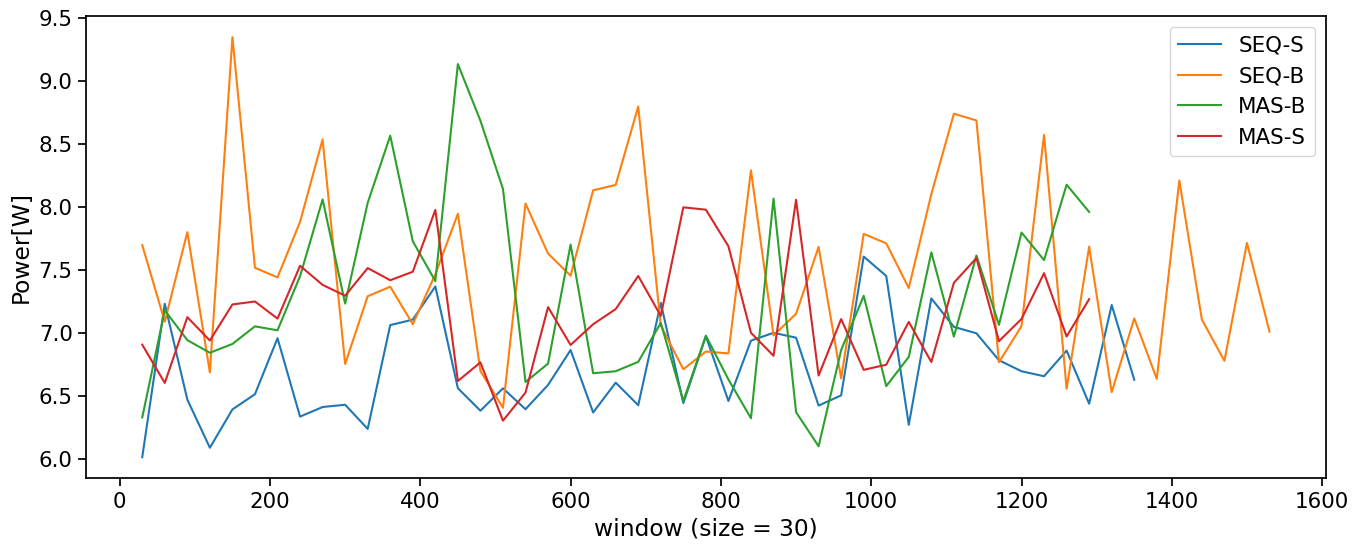

In [244]:
dall_power = pd.concat([dx10_power_w, dx20_power_w, dx30_power_w, dx40_power_w])
dall_power.sort_index().head()

plt.figure(figsize=(16, 6))

ax = sns.lineplot(data=dall_power, x=dall_power.index, y="Power[W]", hue='arch-str')
ax.legend().set_title('')
ax.set_xlabel(f'window (size = {window_size})')

# Save with 600 DPI
plt.savefig("output/power-mean-chart.pdf", format="pdf", dpi=600, bbox_inches="tight")